# Preliminar Exploratory Data Analysis

# Preliminari

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import ast
from pprint import pprint

In [2]:
# Parametri
RAW_DATA_FILE_NAME = 'base.tumoreprimitivo_febbraio.csv'

# Set plot style
plt.style.use('ggplot')
#sns.set_palette('hls')

# Colors
finomnia_palette = sns.color_palette(('#2659ab',
                                      '#db038a',
                                      '#45c9f5',
                                      '#66218a',
                                      '#081c36',))
sns.set_palette(finomnia_palette)

In [3]:
base_dir = Path.cwd().parent

# Load Data

In [4]:
# Get data
data_path = base_dir / 'data' / RAW_DATA_FILE_NAME
data = pd.read_csv(data_path)
data.sort_values(by='id', inplace=True, ignore_index=True)
print(f'{data.shape = }')
display(data.head(2))

data.shape = (343, 45)


,id,profile,discrepanze_rilevate,motivazioni_discrepanze,radiologist,patient_id,sesso,data_nascita,interpretazioni,report_text,...,coinvolgimento_fascia_mesorettale,distanza_minima_fascia_ore,linfonodi_sospetti,numero_linfonodi_non_conosciuto,sedi_locoregionali,sedi_non_locoregionali,depositi_tumorali,numero_depositi,emvi_esteso,status
0,44,IlariaNacci,['nessuna'],nessuna,Barbaro,5667889,M,1976-04-12,dsfgsfsgf,RM SCAVO PELVICO (S/C MDC)\nEsame eseguito med...,...,si,NaN,6.0,False,[],[],si,0.0,no,complete
1,46,GuidoImbemba,['nessuna'],nessuna,Guerrieri Daniele,236893,F,1937-10-08,NaN,"NEL RETTO MEDIO, A CIRCA 7 CM DAL MARGINE ANAL...",...,no,NaN,0.0,True,"['mesorettali', 'sacrali', 'otturatori', 'rett...",[],no,0.0,no,complete


In [5]:
# Referti poco chiari. Sono quelli che hanno la stringa "escludere".
for i, r in data[data['interpretazioni'].str.contains("escludere", case=False, na=False)].iterrows():
    print(f"*--- id referto: {r['id']}\ninterpretazione: {r['interpretazioni']}\n{100*'-'}")
    
r = data[data['id'] == 281].iloc[0]
print(f"*--- id referto: {r['id']}\ninterpretazione: {r['interpretazioni']}\n{100*'-'}")

*--- id referto: 171
interpretazione: FORSE DA ESCLUDERE; REFERTO NON CHIARO

la formazione nodulare è digitazione della neoplasia o linfonodo? in base a questo va compilato. 

non si può sapere se non rivedendo immagini, anche per linfonodi non è chiaro se sono sospetti o no, 
----------------------------------------------------------------------------------------------------
*--- id referto: 259
interpretazione: POCHE INFO; FORSE DA ESCLUDERE

55 mm che misura è? 
credo possa riferirsi a diametro assiale massimo
----------------------------------------------------------------------------------------------------
*--- id referto: 281
interpretazione: tumore non valutabile, solo i linfonodi dati sospetti. 
----------------------------------------------------------------------------------------------------


# Pulisci dati

## Referti poco chiari, da escludere

Stabilito di escludere i seguenti referti dopo il messaggio di Ilario di sabato 17/01/2026

In [6]:
# Referti poco chiari. Sono quelli che hanno la stringa "escludere". anche il referto 281 è da escludere.
rows_to_drop = data[data['id'].isin([171, 259, 281])]
print(rows_to_drop.index)
data = data.drop(index=rows_to_drop.index)
data.reset_index(inplace=True, drop=True)

Index([107, 194, 206], dtype='int64')


## Pulizia doppioni

In [7]:
# Rimuovi righe duplicate
print(f'Shape iniziale: {data.shape}')

# Intere righe duplicate. Keep last perchè i report hanno id crescente
duplicati = data.iloc[:, 1:].duplicated(keep='last')
print(f'Numero righe duplicate: {duplicati.sum()}')

data_clean = data[duplicati == False]
print('Righe doppie eliminate')

Shape iniziale: (340, 45)
Numero righe duplicate: 2
Righe doppie eliminate


In [8]:
# Rimuovi righe con report duplicati
duplicati = data_clean['report_text'].duplicated(keep='last')
righe_report_duplicato = data_clean[duplicati]
print(f'Numero righe con stesso referto: {duplicati.sum()}')

data_clean = data_clean[duplicati == False]
print('Righe eliminate')

data_clean.reset_index(inplace=True, drop=True)

print(f'{data_clean.shape = }')

Numero righe con stesso referto: 22
Righe eliminate
data_clean.shape = (316, 45)


In [9]:
# Cambia indice al dataset
data_clean.set_index('id', inplace=True)

## Anomalie

In [ ]:
n = 'linfonodi_sospetti'
sn = 'stadio_N'
flag_n = 'numero_linfonodi_non_conosciuto'
loco = 'sedi_locoregionali'
non_loco = 'sedi_non_locoregionali'
fascia = 'coinvolgimento_fascia_mesorettale'
mrf = 'mrf'
spessore = 'spessore_parietale'
estensione_cc= 'estensione_cranio_caudale'
ofine = 'ore_fine'
oinizio = 'ore_inizio'
oai = 'distanza_oai'
M = 'metastasi'
infiltrazione_tessuto = 'infiltrazione_tessuto_adiposo'
pos = 'posizione_multiple'
coin_peritoneo = 'coinvolgimento_riflessione_peritoneale'
relaz = 'riflessione_peritoneale_anteriore'
sfinteri = 'infiltrazione_sfinteri'

### Referti che hanno lo stesso commento

In [11]:
interpretazioni_duplicate = data_clean['interpretazioni'].dropna()[data_clean['interpretazioni'].dropna().duplicated(keep=False)].to_frame().sort_values(by=['interpretazioni', 'id'])
#display(interpretazioni_duplicate)

nota = ''
lista = []
for i, row in interpretazioni_duplicate.iterrows():
    if row['interpretazioni'] != nota:
        if lista != []:
            print(lista)
        lista = [i]
        nota = row['interpretazioni']
    else:
        lista.append(i)

[196, 198, 199, 200, 201]
[215, 216, 217, 218, 219, 220]
[195, 197]
[156, 229]
[91, 92]
[397, 398, 401]
[403, 410, 411]
[207, 209, 210]
[139, 140, 141, 142]
[168, 170]
[55, 57]
[317, 318, 322, 323, 324, 325, 326, 330, 331]


### Posizione

In [12]:
data_clean.loc[44, 'posizione_multiple'] = "['basso', 'medio']"
data_clean.loc[120, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[126, 'posizione_multiple'] = "['alto', 'giunzione']" # Prima era ['giunzione']
data_clean.loc[140, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['basso']
data_clean.loc[184, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[186, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[204, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['medio']
data_clean.loc[209, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[221, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[316, 'posizione_multiple'] = "['basso', 'medio', 'alto']" # Prima era ['basso']
data_clean.loc[326, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']

data_clean.loc[53, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[56, 'posizione_multiple'] = "['medio']" # Prima era ['basso']
data_clean.loc[78, 'posizione_multiple'] = "['basso', 'medio', 'alto']" # Prima era ['medio']
data_clean.loc[137, 'posizione_multiple'] = "['medio', 'alto', 'giunzione']" # Prima era ['giunzione']
data_clean.loc[180, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[183, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['medio']
data_clean.loc[189, 'posizione_multiple'] = "['alto', 'giunzione']" # Prima era ['alto'] # Controllare meglio
data_clean.loc[202, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[205, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[211, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[212, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[217, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
#### incongruuenza in referto data_clean.loc[220, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['medio']

data_clean.loc[77, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[127, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[128, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[134, 'posizione_multiple'] = "['basso', 'medio', 'alto']" # Prima era ['basso'] # Da controllare bene ma mi sembra giusto scrivere basso medio e alto
data_clean.loc[139, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['basso']
data_clean.loc[144, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['basso']
data_clean.loc[177, 'posizione_multiple'] = "['alto', 'giunzione']" # Prima era ['giunzione']
data_clean.loc[192, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['medio']
data_clean.loc[198, 'posizione_multiple'] = "['basso', 'medio']" # Prima era ['medio']
data_clean.loc[200, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']
data_clean.loc[206, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['medio']
data_clean.loc[219, 'posizione_multiple'] = "['medio', 'alto']" # Prima era ['alto']


### Distanza OAI

In [13]:
data_clean.loc[
    57, ['distanza_oai', 'linfonodi_sospetti', 'sedi_locoregionali']
    ] = [0, 3, "['mesorettali', 'otturatori']"]

data_clean.loc[
    106, ['distanza_oai', 'linfonodi_sospetti', 'sedi_locoregionali', 'sedi_non_locoregionali', 'metastasi']
    ] = [0, 0, "[]", "[]", "MX"]

data_clean.loc[160, ['distanza_oai', 'linfonodi_sospetti']] = [0, 3]

data_clean.loc[163, ['morfologia', 'ore_inizio', 'ore_fine']] = ['solido_polipoide', 6, 9]

data_clean.loc[
    185, ['distanza_oai', 'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto']
    ] = [70, 4, False]

data_clean.loc[
    208, ['distanza_oai', 'linfonodi_sospetti', 'estensione_cranio_caudale']
    ] = [0, 2, 60]

data_clean.loc[232, ['ore_inizio', 'ore_fine']] = [8, 1]

data_clean.loc[234, ['distanza_oai', 'linfonodi_sospetti']] = [0, 4]

data_clean.loc[
    271, ['mrf', 'coinvolgimento_fascia_mesorettale', 'ore_inizio', 'ore_fine']
    ] = ['-', 'no', 11, 4]

data_clean.loc[
    307, ['distanza_oai', 'ore_inizio', 'ore_fine',
          'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'stadio_N', 'sedi_locoregionali', 'sedi_non_locoregionali']
    ] = [0, 2, 7, 0, False, 'N0', "[]", "[]"]

data_clean.loc[
    310, ['ore_inizio', 'ore_fine', 'linfonodi_sospetti', 'metastasi']
    ] = [12, 12, 9, 'M1']

data_clean.loc[
    313, ['ore_inizio', 'ore_fine', 'linfonodi_sospetti', 'distanza_oai', M]
    ] = [12, 12, 2, 0, 'MX']

data_clean.loc[314, ['ore_inizio', 'ore_fine', 'distanza_oai']] = [8, 1, 0]

data_clean.loc[
    322, ['distanza_oai', 'ore_inizio', 'ore_fine',
          'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'stadio_N']
    ] = [0, 12, 12, 1, True, 'N+']

data_clean.loc[
    323, ['distanza_oai', 'ore_inizio', 'ore_fine',
          'mrf', 'coinvolgimento_fascia_mesorettale', 'metastasi']
    ] = [0, 3, 9, '-', 'no', 'MX']

data_clean.loc[
    335, ['distanza_oai', 'morfologia',
          'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'stadio_N', 'sedi_locoregionali']
    ] = [0, 'mucinoso', 1, True, 'N+', "['sacrali']"]

data_clean.loc[336, ['distanza_oai', 'ore_inizio', 'ore_fine', 'linfonodi_sospetti']] = [0, 6, 12, 5]
data_clean.loc[340, ['distanza_oai', 'ore_inizio', 'ore_fine', 'mrf']] = [0, 12, 12, '-']
data_clean.loc[348, ['distanza_oai', 'spessore_parietale', 'sedi_locoregionali']] = [0, 20, "[]"]
data_clean.loc[354, ['linfonodi_sospetti']] = [4]
data_clean.loc[
    357, ['ore_inizio', 'ore_fine', 'linfonodi_sospetti', 'sedi_locoregionali']
    ] = [12, 12, 4, "['mesorettali', 'rettali_superiori']"]

data_clean.loc[
    359, ['distanza_oai', 'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'stadio_N', 'sedi_locoregionali']
    ] = [0, 0, False, 'N0', "[]"]

data_clean.loc[362, ['distanza_oai', 'linfonodi_sospetti', 'ore_inizio', 'ore_fine']] = [0, 1, 3, 9]
data_clean.loc[366, ['distanza_oai', 'mrf']] = [0, '-']

data_clean.loc[
    384,['distanza_oai', 'mrf', 'emvi', 'emvi_esteso', 'linfonodi_sospetti', 'sedi_locoregionali']
    ] = [0, '-', '-', 'no', 1, "['otturatori']"]

data_clean.loc[387,['sedi_non_locoregionali', 'metastasi']] = ["['iliaci_esterni']", 'M1']

data_clean.loc[
    388,['distanza_oai', 'ore_inizio', 'ore_fine','linfonodi_sospetti',
         'sedi_locoregionali', 'sedi_non_locoregionali', 'numero_linfonodi_non_conosciuto', 'stadio_N']
    ] = [0, 12, 12, 0, "[]", "[]", False, 'N0']

data_clean.loc[394, ['distanza_oai', 'ore_inizio', 'ore_fine']] = [0, 12, 12]
data_clean.loc[399,['distanza_oai', 'linfonodi_sospetti', 'emvi', 'emvi_esteso', M]] = [0, 4, '+', 'si', 'M1']

data_clean.loc[
    411, ['distanza_oai', 'linfonodi_sospetti', 'ore_inizio', 'ore_fine', 'numero_linfonodi_non_conosciuto']
    ] = [0, 2, 12, 9, True]

data_clean.loc[
    418, ['distanza_oai', 'linfonodi_sospetti', 'sedi_locoregionali', 'sedi_non_locoregionali',
         'numero_linfonodi_non_conosciuto', 'stadio_N', 'mrf', 'coinvolgimento_fascia_mesorettale']
    ] = [0, 0, "[]", "[]", False, 'N0', '-', 'no']

data_clean.loc[420, ['distanza_oai', 'linfonodi_sospetti', 'metastasi']] = [0, 1, 'MX']
data_clean.loc[67, [relaz]] = [None]

data_clean.loc[
    125, ['distanza_oai', 'posizione_multiple', 'infiltrazione_tessuto_adiposo', 'stadio_T', 'sedi_non_locoregionali',
         'mrf', 'coinvolgimento_fascia_mesorettale', 'sedi_locoregionali', 'linfonodi_sospetti']
    ] = [45, "['basso', 'medio']", 'si_5mm_plus', 'T3cd', "[]",
         '+', 'si', "['mesorettali', 'rettali_superiori']", 4]
    
data_clean.loc[
    166, ['morfologia', 'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'estensione_cranio_caudale']
    ] = ['solido_polipoide', 4, True, 40]

data_clean.loc[
    179, ['distanza_oai', 'ore_inizio', 'ore_fine',
          'sedi_non_locoregionali', 'numero_linfonodi_non_conosciuto', 'stadio_N', 'metastasi']
    ] = [0, 12, 6, "[]", True, 'N+', 'MX']

data_clean.loc[
    187, ['distanza_oai', 'posizione_multiple', 'emvi', 'emvi_esteso','linfonodi_sospetti',
          'numero_linfonodi_non_conosciuto', 'stadio_N']
    ] = [0, "['basso', 'medio']", '+', 'si', 4, True, 'N+']

data_clean.loc[213, ['distanza_oai', 'ore_inizio', 'ore_fine']] = [0, 3, 9]

In [14]:
data_clean.loc[120, [spessore]] = [None]
data_clean.loc[120, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[140, [n, flag_n, loco, sn]] = [4, True, "['mesorettali', 'rettali_superiori']", 'N+']

data_clean.loc[184, [oinizio, ofine, oai, flag_n]] = [12, 12, 60, True]

data_clean.loc[186, [oinizio, ofine, n, flag_n, loco]] = [12, 12, 4, True, "['mesorettali']"]

data_clean.loc[204, [oinizio, ofine]] = [12, 9]
data_clean.loc[204, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[209, [oinizio, ofine, n]] = [6, 3, 4]

data_clean.loc[221, [oinizio, ofine]] = [12, 12]
data_clean.loc[221, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[316, [M, n, sn]] = ['M1', 4, 'N+']

data_clean.loc[326, [oinizio, ofine, n, non_loco, M]] = [12, 12, 4, "[]", 'MX']

data_clean.loc[53, [oinizio, ofine, spessore, estensione_cc]] = [12, 12, 27, 65]
data_clean.loc[53, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[56, [spessore, oai]] = [None, 87]
data_clean.loc[56, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[78, [oai, fascia, mrf, n, flag_n]] = [None, 'si', '+', 4, True]

data_clean.loc[137, [loco, non_loco, M]] = ["['mesorettali']", "['iliaci_comuni']", 'M1']

data_clean.loc[180, [oinizio, ofine, loco]] = [12, 9, "['mesorettali', 'rettali_superiori']"]

data_clean.loc[189, [spessore, oai, oinizio, ofine]] = [6, 70, 9, 3]
data_clean.loc[189, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[202, [oinizio, ofine]] = [6, 12]
data_clean.loc[202, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[211, [oinizio, ofine, estensione_cc]] = [12, 12, 40]
data_clean.loc[211, [n, flag_n, loco, non_loco, sn]] = [4, True, "['mesorettali']", "[]", 'N+']

data_clean.loc[212, [oinizio, ofine, oai]] = [5, 10, 70]
data_clean.loc[212, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[217, [oinizio, ofine]] = [12, 12]

data_clean.loc[220, [oinizio, ofine, flag_n, infiltrazione_tessuto]] = [2, 7, True, 'si_5mm_plus']

data_clean.loc[77, [fascia, mrf]] = ['no', '-']

data_clean.loc[127, [oinizio, ofine]] = [8, 4]
data_clean.loc[127, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[128, [oinizio, ofine]] = [3, 12]
data_clean.loc[128, [n, flag_n, sn]] = [4, True, 'N+']

data_clean.loc[134, [oinizio, ofine, n, loco, flag_n]] = [9, 3, 4, "['rettali_superiori']", True]

data_clean.loc[139, [oinizio, ofine, fascia, mrf, non_loco, n, M]] = [5, 1, 'si', '+', "[]", 4, 'MX']

data_clean.loc[144, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[177, [n, flag_n, sn, M]] = [4, True, 'N+', 'M1']

data_clean.loc[192, [oinizio, ofine]] = [8, 1]

data_clean.loc[198, [oinizio, ofine, n]] = [12, 12, 4]

data_clean.loc[200, [n]] = [4]

data_clean.loc[206, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N+']


data_clean.loc[46, [n]] = [4]
data_clean.loc[66, [n, flag_n]] = [4, True]
data_clean.loc[74, [oinizio, ofine]] = [5, 10]
data_clean.loc[87, [oinizio, ofine]] = [9, 6]
data_clean.loc[88, [oinizio, ofine, n, flag_n, mrf, fascia]] = [6, 9, 3, True, '-', 'no']
data_clean.loc[92, [n, flag_n]] = [5, True]
data_clean.loc[98, [n, flag_n]] = [4, True]
data_clean.loc[116, [oinizio, ofine, n, flag_n]] = [4, 11, 4, True]
data_clean.loc[129, [n, flag_n]] = [4, True]
data_clean.loc[130, [pos, flag_n, loco, non_loco, M]] = [
    "['alto', 'giunzione']", True, "['mesorettali', 'rettali_superiori']", "[]", 'MX']
data_clean.loc[131, [n, flag_n, loco, non_loco, sn, estensione_cc, spessore]] = [
    0, False, "[]", "[]", 'N+', 40, None]
data_clean.loc[132, [oinizio, ofine, spessore, sn, loco, non_loco, n, flag_n]] = [
    12, 12, None, 'N+', "['mesorettali', 'rettali_superiori']", "[]", 4, True]
data_clean.loc[178, [oinizio, ofine, estensione_cc, loco, non_loco]] = [
    12, 9, 50, "['mesorettali', 'rettali_superiori']", "[]"]
data_clean.loc[181, [n]] = [6]
data_clean.loc[190, [oinizio, ofine, loco, non_loco, mrf, fascia]] = [
    9, 3, "['mesorettali']", "[]", "-", "no"]

data_clean.loc[193, [oinizio, ofine, oai, mrf, fascia]] = [12, 12, 54, "-", "no"]
data_clean.loc[193, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[195, [oinizio, ofine, n]] = [12, 12, 4]
data_clean.loc[196, [oinizio, ofine, mrf, fascia]] = [3, 12, "-", "no"]
data_clean.loc[199, [estensione_cc]] = [30]
data_clean.loc[207, [estensione_cc, n]] = [35, 4]
data_clean.loc[210, [estensione_cc, oai, fascia, mrf, 'emvi_esteso', 'emvi']] = [
    38, 100, "no", "-", "si", "+"]
data_clean.loc[214, [oinizio, ofine, M]] = [8, 4, 'MX']
data_clean.loc[227, ['morfologia', coin_peritoneo, fascia, mrf]] = ['solido_polipoide', "no", "no", "-"]
data_clean.loc[229, [oinizio, ofine, coin_peritoneo, fascia, mrf]] = [12, 6, "no", "no", "-"]
data_clean.loc[230, [oinizio, ofine, n, flag_n, M]] = [5, 10, 1, True, 'MX']
data_clean.loc[237, [pos]] = ["['medio', 'alto', 'giunzione']"]
data_clean.loc[242, [oinizio, ofine]] = [8, 1]
data_clean.loc[244, [n]] = [4]
data_clean.loc[250, [n, flag_n]] = [4, True]
data_clean.loc[251, [oinizio, ofine]] = [12, 6]
data_clean.loc[257, [oinizio, ofine, n, flag_n, fascia, mrf]] = [12, 12, 4, True, 'no', '-']
data_clean.loc[258, [n, flag_n]] = [4, True]
data_clean.loc[260, [n, flag_n, sfinteri, fascia, mrf, coin_peritoneo]] = [
    3, False, 'interno', 'no', '-', 'no']
data_clean.loc[262, [oinizio, ofine]] = [9, 3]
data_clean.loc[263, [oinizio, ofine]] = [5, 10]
data_clean.loc[270, [oinizio, ofine, fascia, mrf]] = [9, 3, 'no', '-']
data_clean.loc[273, [oinizio, ofine, fascia, mrf]] = [3, 12, 'no', '-']
data_clean.loc[275, [fascia, mrf]] = ['no', '-']
data_clean.loc[284, [oai, estensione_cc, fascia, mrf]] = [0, 45, 'no', '-']
data_clean.loc[288, [oinizio, ofine]] = [12, 12]
data_clean.loc[294, [oinizio, ofine]] = [8, 1]
data_clean.loc[295, [fascia, mrf]] = ['no', '-']
data_clean.loc[296, [oinizio, ofine]] = [9, 3]
data_clean.loc[298, [fascia, mrf]] = ['no', '-']
data_clean.loc[300, [fascia, mrf]] = ['no', '-']
data_clean.loc[302, [oinizio, ofine]] = [6, 3]
data_clean.loc[305, [fascia, mrf]] = ['no', '-']
data_clean.loc[311, [oinizio, ofine, n, flag_n]] = [3, 12, 4, True]
data_clean.loc[312, [oinizio, ofine]] = [12, 6]
data_clean.loc[315, [oinizio, ofine, fascia, mrf]] = [9, 3, 'no', '-']
data_clean.loc[318, [oinizio, ofine, fascia, mrf, n, flag_n]] = [3, 9, 'no', '-', 1, True]
data_clean.loc[320, [fascia, mrf]] = ['no', '-']

data_clean.loc[324, [oinizio, ofine, fascia, mrf, coin_peritoneo]] = [6, 12, 'no', '-', 'no']
data_clean.loc[324, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[325, [fascia, mrf]] = ['no', '-']
data_clean.loc[329, [oinizio, ofine, n, flag_n]] = [12, 12, 4, True]

data_clean.loc[331, [oinizio, ofine, fascia, mrf, M]] = [8, 10, 'no', '-', 'MX']
data_clean.loc[331, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[333, [oinizio, ofine]] = [12, 12]
data_clean.loc[333, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N+']

data_clean.loc[334, [n, flag_n, sn]] = [4, True, 'N+']
data_clean.loc[338, [oinizio, ofine, M, non_loco]] = [12, 12, 'MX', "[]"]
data_clean.loc[342, [oinizio, ofine]] = [9, 12]
data_clean.loc[343, [n, flag_n, loco, non_loco]] = [3, False, "['mesorettali', 'iliaci_interni']", "[]"]
data_clean.loc[344, [oinizio, ofine]] = [5, 1]
data_clean.loc[345, [oinizio, ofine, n, flag_n]] = [9, 6, 4, True]
data_clean.loc[346, [oinizio, ofine, n, flag_n, sn]] = [5, 1, 4, True, 'N+']
data_clean.loc[347, [n, flag_n, loco, non_loco, sn, fascia, mrf]] = [0, False, "[]", "[]", 'N0', 'no', '-']
data_clean.loc[349, [n, flag_n, fascia, mrf]] = [1, True, 'no', '-']

data_clean.loc[350, [oinizio, ofine]] = [12, 12]
data_clean.loc[350, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[351, [oinizio, ofine]] = [12, 6]
data_clean.loc[352, [oinizio, ofine, n, flag_n]] = [6, 3, 1, True]
data_clean.loc[353, [oinizio, ofine, n]] = [3, 6, 1]
data_clean.loc[355, [oinizio, ofine, infiltrazione_tessuto, 'stadio_T', n, flag_n]] = [
    3, 9, 'no', 'T1-2', 2, True]
data_clean.loc[356, [oinizio, ofine, n, sn, fascia, mrf]] = [12, 12, 2, 'N+', 'no', '-']
data_clean.loc[358, [oinizio, ofine, fascia, mrf]] = [5, 7, 'no', '-']
data_clean.loc[360, [oinizio, ofine, 'emvi_esteso', 'emvi', fascia, mrf]] = [
    12, 6, 'no', '-', 'no', '-']
data_clean.loc[361, [oinizio, ofine, n, flag_n, fascia, mrf]] = [12, 12, 4, True, 'no', '-']

data_clean.loc[363, [oinizio, ofine, 'morfologia']] = [2, 7, 'solido_polipoide']
data_clean.loc[363, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[364, [oinizio, ofine]] = [6, 3]

data_clean.loc[365, [oinizio, ofine, M]] = [12, 12, 'MX']
data_clean.loc[365, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[367, [oinizio, ofine]] = [12, 12]
data_clean.loc[367, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N+']

data_clean.loc[368, [oinizio, ofine, n, flag_n]] = [12, 12, 4, True]
data_clean.loc[369, [fascia, mrf]] = ['no', '-']

data_clean.loc[370, [oinizio, ofine]] = [12, 12]
data_clean.loc[370, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[371, [oinizio, ofine, n, flag_n, sn]] = [12, 12, 4, True, 'N+']
data_clean.loc[373, [oinizio, ofine, fascia, mrf]] = [9, 3, 'no', '-']
data_clean.loc[374, [oinizio, ofine, n, flag_n]] = [11, 4, 4, True]
data_clean.loc[375, [oinizio, ofine, n, sn, flag_n]] = [12, 12, 4, 'N+', True]
data_clean.loc[376, [fascia, mrf]] = ['no', '-']
data_clean.loc[377, [oinizio, ofine, relaz, n, flag_n]] = [5, 1, 'cavallo', 1, True]
data_clean.loc[379, [oinizio, ofine, n, flag_n]] = [2, 10, 4, True]
data_clean.loc[380, [oinizio, ofine]] = [11, 7]
data_clean.loc[381, [oinizio, ofine, n, flag_n]] = [8, 4, 4, True]

data_clean.loc[386, [oinizio, ofine]] = [12, 9]
data_clean.loc[386, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[389, [oinizio, ofine, M]] = [5, 10, 'M1']
data_clean.loc[389, [n, flag_n, loco, non_loco, sn]] = [1, False, "[]", "['iliaci_esterni']", 'N+']

data_clean.loc[392, [oinizio, ofine]] = [12, 12]
data_clean.loc[392, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[393, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[395, [oinizio, ofine]] = [12, 12]
data_clean.loc[395, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N+']

data_clean.loc[396, [oinizio, ofine, n, flag_n]] = [6, 12, 1, False]
data_clean.loc[397, [oinizio, ofine, n, flag_n]] = [3, 12, 4, True]

data_clean.loc[400, [oinizio, ofine, pos]] = [2, 8, "['medio', 'alto', 'giunzione']"]
data_clean.loc[400, [n, flag_n, sn, M]] = [4, True, 'N+', 'M1']

data_clean.loc[401, [n, flag_n, sn, fascia, mrf]] = [1, True, 'N+', 'no', '-']

data_clean.loc[402, [n, flag_n, loco, non_loco, sn, fascia, mrf]] = [
    0, False, "[]", "[]", 'N0', 'no', '-']

data_clean.loc[403, [oinizio, ofine, M]] = [4, 11, 'MX']
data_clean.loc[403, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[407, [oinizio, ofine, n, sn, flag_n]] = [12, 12, 4, 'N+', False]
data_clean.loc[409, [oinizio, ofine, n, flag_n]] = [3, 9, 4, True]

data_clean.loc[410, [oinizio, ofine]] = [12, 12]
data_clean.loc[410, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N+']

data_clean.loc[412, [oinizio, ofine]] = [12, 6]
data_clean.loc[412, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N+']

data_clean.loc[413, [oinizio, ofine, n, flag_n, sn, M]] = [12, 12, 4, True, 'N+', 'M1']
data_clean.loc[415, [n, flag_n, sn, M]] = [4, True, 'N+', 'MX']
data_clean.loc[416, [n, flag_n, sn, M, loco, non_loco]] = [
    4, True, 'N+', 'MX', "['otturatori', 'iliaci_interni']", "[]"]
data_clean.loc[419, [M, n, flag_n]] = ['MX', 4, True]
data_clean.loc[421, [oinizio, ofine, estensione_cc, n, loco, non_loco, sn, flag_n, M]] = [
    3, 12, 68, 3, "['mesorettali']", "[]", 'N+', False, 'MX']
data_clean.loc[422, [oinizio, ofine, n, flag_n, sn]] = [12, 12, 6, True, 'N+']
data_clean.loc[75, [oinizio, ofine]] = [5, 7]
data_clean.loc[79, [oinizio, ofine]] = [5, 1]
data_clean.loc[100, [oinizio, ofine, n, flag_n]] = [2, 10, 4, True]
data_clean.loc[104, ['morfologia']] = ['solido_polipoide']
data_clean.loc[115, [n, flag_n]] = [4, True]
data_clean.loc[135, [oinizio, ofine, pos, n, flag_n]] = [
    12, 12, "['medio', 'alto', 'giunzione']", 4, True]
data_clean.loc[136, [n, flag_n]] = [4, True]

data_clean.loc[141, [oinizio, ofine, fascia, mrf, M]] = [6, 9, 'no', '-', 'MX']
data_clean.loc[141, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[142, [oinizio, ofine, fascia, mrf, n, flag_n]] = [6, 3, 'si', '+', 4, True]
data_clean.loc[162, [n, flag_n]] = [4, True]
data_clean.loc[170, [n, flag_n, relaz, fascia, mrf]] = [3, True, 'cavallo', 'no', '-']
data_clean.loc[173, [n, flag_n]] = [4, True]
data_clean.loc[175, [n, flag_n]] = [4, True]
data_clean.loc[203, [oinizio, ofine, pos, estensione_cc, fascia, mrf]] = [
    12, 12, "['medio', 'alto']", 55, 'si', '+']
data_clean.loc[215, [oinizio, ofine, infiltrazione_tessuto, coin_peritoneo, 'stadio_T', M]] = [
    6, 9, 'si_5mm', 'no', 'T3ab', 'MX']
data_clean.loc[226, [n, flag_n]] = [10, True]
data_clean.loc[228, [oinizio, ofine]] = [12, 12]
data_clean.loc[238, [n, flag_n]] = [4, True]
data_clean.loc[245, [n, flag_n, spessore]] = [1, True, 20]
data_clean.loc[247, [oinizio, ofine, n, flag_n]] = [11, 7, 4, True]
data_clean.loc[255, [oinizio, ofine]] = [12, 12]
data_clean.loc[261, [fascia, mrf]] = ['no', '-']
data_clean.loc[269, [oinizio, ofine]] = [5, 10]
data_clean.loc[272, [fascia, mrf]] = ['no', '-']
data_clean.loc[283, [oinizio, ofine]] = [12, 6]
data_clean.loc[293, [oinizio, ofine]] = [2, 7]
data_clean.loc[299, [oinizio, ofine, loco, non_loco, n, flag_n]] = [8, 4, "['mesorettali']", "[]", 4, True]
data_clean.loc[304, [oinizio, ofine, n, flag_n, fascia, mrf]] = [12, 9, 6, True, 'no', '-']
data_clean.loc[308, [oinizio, ofine, n, flag_n]] = [12, 12, 1, True]
data_clean.loc[332, [n, flag_n]] = [4, True]
data_clean.loc[372, [oinizio, ofine, n, flag_n, sn]] = [12, 12, 1, True, 'N+']
data_clean.loc[52, [oinizio, ofine, M]] = [5, 10, 'MX']
data_clean.loc[62, [estensione_cc]] = [29]
data_clean.loc[63, [oinizio, ofine]] = [1, 5]
data_clean.loc[71, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[72, [oinizio, ofine]] = [12, 12]
data_clean.loc[72, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N+']

data_clean.loc[73, [oinizio, ofine]] = [5, 1]
data_clean.loc[81, [oinizio, ofine, n, sn, flag_n]] = [10, 2, 1, 'N+', False]
data_clean.loc[83, [n, sn, flag_n]] = [4, 'N+', True]
data_clean.loc[91, [oinizio, ofine]] = [3, 9]
data_clean.loc[94, [oinizio, ofine]] = [5, 10]
data_clean.loc[95, [oinizio, ofine, estensione_cc, oai]] = [12, 6, 20, 0]
data_clean.loc[101, [oinizio, ofine, fascia, mrf]] = [9, 3, 'no', '-']
data_clean.loc[103, [oinizio, ofine, fascia, mrf]] = [2, 7, 'no', '-']
data_clean.loc[105, [oinizio, ofine, n, flag_n, loco, non_loco, sn, fascia, mrf]] = [
    11, 7, 1, False, "['otturatori']", "[]", 'N+', 'no', '-']

data_clean.loc[107, [oinizio, ofine, spessore, fascia, mrf]] = [None, None, None, 'no', '-']
data_clean.loc[107, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[117, [n, flag_n, fascia, mrf]] = [4, True, 'no', '-']
data_clean.loc[118, [oinizio, ofine, n, flag_n]] = [9, 6, 4, True]

data_clean.loc[133, [oinizio, ofine]] = [2, 8]
data_clean.loc[133, [n, flag_n, loco, non_loco, sn]] = [0, False, "[]", "[]", 'N0']

data_clean.loc[138, [oinizio, ofine, fascia, mrf]] = [5, 1, 'no', '-']

data_clean.loc[143, [oinizio, ofine, oai, n, flag_n, loco, non_loco, M, fascia, mrf]] = [
    12, 12, 100, 4, True, "['mesorettali']", "[]", 'MX', 'no', '-']
data_clean.loc[157, [oinizio, ofine, n, flag_n]] = [5, 7, 4, True]
data_clean.loc[159, ['morfologia', n, flag_n, pos]] = ["solido_polipoide", 13, True, "['basso', 'alto']"]
data_clean.loc[164, [oinizio, ofine, fascia, mrf]] = [9, 12, 'no', '-']
data_clean.loc[168, [oinizio, ofine, n , flag_n]] = [6, 3, 4, True]
data_clean.loc[169, [oinizio, ofine, fascia, mrf]] = [9, 3, 'no', '-']
data_clean.loc[182, [oinizio, ofine]] = [11, 7]
data_clean.loc[197, [n, flag_n]] = [6, True]
data_clean.loc[201, [oai]] = [None]
data_clean.loc[203, [n, flag_n, fascia, mrf]] = [5, True, 'no', '-']
data_clean.loc[218, [oinizio, ofine, non_loco, M, fascia, mrf]] = [9, 3, "[]", 'MX', 'no', '-']
data_clean.loc[219, [oinizio, ofine, pos, flag_n]] = [12, 12, "['medio', 'alto']", True]
data_clean.loc[233, [oinizio, ofine]] = [8, 4]
data_clean.loc[240, [oinizio, ofine, n, flag_n]] = [11, 4, 4, True]
data_clean.loc[249, [oinizio, ofine, n, loco, sn, flag_n]] = [
    8, 1, 4, "['mesorettali', 'iliaci_interni']", "N+", False]
data_clean.loc[252, [n, flag_n, fascia, mrf, oai]] = [4, True, 'no', '-', None]
data_clean.loc[317, [oinizio, ofine]] = [9, 3]
data_clean.loc[330, ['morfologia', n, flag_n]] = ['solido_polipoide', 4, True]
data_clean.loc[382, [n, flag_n, fascia, mrf]] = [2, False, 'no', '-']
data_clean.loc[383, [oinizio, ofine]] = [12, 12]
data_clean.loc[121, [fascia, mrf]] = ['no', '-']

### Stadio N

numero linfonodi sospetti -> valore N corrispondente delle Conclusioni sulla base della classificazione

Depositi tumorali mesorettali Sì -> aggiunta di valore N1c al campo N delle Conclusioni

Cambiato dopo call del 9 marzo: ora lo stadio N è solo N0 o N+. N+ comprende anche il caso dei depositi tumorali.

In [15]:
# Stadio N non valorizzato o valorizato con "N1c" 
df = data_clean[
    (data_clean['stadio_N'].isna()) | (data_clean['stadio_N'] == 'N1c')
    ][
        ['profile', 'linfonodi_sospetti', 'depositi_tumorali', 'numero_depositi', 'stadio_N1c', 'stadio_N']
    ]
display(df)
print(f'id referti con stadio N anomalo= {df.index.tolist()}')

,profile,linfonodi_sospetti,depositi_tumorali,numero_depositi,stadio_N1c,stadio_N
id,,,,,,
44,IlariaNacci,6.0,si,0.0,False,N1c


id referti con stadio N anomalo= [44]


In [16]:
# Correggiamo stadio N
data_clean.loc[44, 'stadio_N1c'] = True
data_clean.loc[44, 'stadio_N'] = 'N+'

In [17]:
display(data_clean[data_clean.linfonodi_sospetti.isna()][
    ['linfonodi_sospetti', 'stadio_N', 'depositi_tumorali', 'numero_linfonodi_non_conosciuto', 'sedi_locoregionali', 'sedi_non_locoregionali']
])

,linfonodi_sospetti,stadio_N,depositi_tumorali,numero_linfonodi_non_conosciuto,sedi_locoregionali,sedi_non_locoregionali
id,,,,,,


### EMVI

Per quanto riguarda tutti i referti relativi il campo EMVI, ho controllato oltre la metà di questi da voi riportati e in tutti in realtà nei campi di compilazione era indicato EMVI sì, mentre nelle conclusioni era EMVI -. per questi c’è stato sicuramente un problema con la maschera in quanto l’opzione corretta è sempre EMVI - e EMVI no

In [19]:
# EMVI anomalo

df = data_clean[
    ((data_clean['emvi'] == '+') & (data_clean['emvi_esteso'] == 'no'))
    ][
        ['profile', 'emvi_esteso', 'emvi']
    ]
display(df)
print(f'id referti con EMVI anomalo= {df.index.tolist()}')

# Correzione
data_clean.loc[
    (data_clean['emvi'] == '+') &
    (data_clean['emvi_esteso'] == 'no')
    , 'emvi'
    ] = '-'

data_clean.loc[
    (data_clean['emvi'].isna()) &
    (data_clean['emvi_esteso'] == 'sospetto')
    , 'emvi'
    ] = '+'

,profile,emvi_esteso,emvi
id,,,
130,PietroPaoloAzzaro,no,+
132,PietroPaoloAzzaro,no,+
192,PietroPaoloAzzaro,no,+
332,PietroPaoloAzzaro,no,+
335,PietroPaoloAzzaro,no,+
338,PietroPaoloAzzaro,no,+
347,PietroPaoloAzzaro,no,+
358,PietroPaoloAzzaro,no,+
361,PietroPaoloAzzaro,no,+


id referti con EMVI anomalo= [130, 132, 192, 332, 335, 338, 347, 358, 361, 368, 369, 370, 372, 373, 374, 376, 387, 388, 389, 396, 397, 398, 401, 403, 410, 411, 419, 420]


### MRF

se fascia mesorettale coinvolta -> mrf +, altrimenti dipende dallo stadio T

Se T4b metto +

In [20]:
# mrf anomalo

df = data_clean[
    ((data_clean['mrf'].isna()) & (data_clean['coinvolgimento_fascia_mesorettale'] == 'rischio'))
    ][
        ['profile', 'coinvolgimento_fascia_mesorettale', 'infiltrazione_organi_dettagli', 'stadio_T', 'mrf']
    ]
display(df)

df = data_clean[
    ((data_clean['mrf'].isna()) & (data_clean['coinvolgimento_fascia_mesorettale'].isna()))
    ][
        ['profile', 'coinvolgimento_fascia_mesorettale', 'infiltrazione_organi_dettagli', 'stadio_T', 'mrf']
    ]
display(df)

df = data_clean[
    ((data_clean['mrf'].isna()) & (data_clean['coinvolgimento_fascia_mesorettale'].isna()) & (data_clean['stadio_T'] == 'T4b'))
    ][
        ['profile', 'coinvolgimento_fascia_mesorettale', 'infiltrazione_organi_dettagli', 'stadio_T', 'mrf']
    ]
display(df)

# Risoluzione anomalie
data_clean.loc[
    (data_clean['mrf'].isna()) &
    (data_clean['coinvolgimento_fascia_mesorettale'] == 'rischio')
    , 'mrf'
    ] = '+'

data_clean.loc[
    (data_clean['coinvolgimento_fascia_mesorettale'].isna())
    , ['mrf', 'coinvolgimento_fascia_mesorettale']
    ] = ['-', 'no'] 


,profile,coinvolgimento_fascia_mesorettale,infiltrazione_organi_dettagli,stadio_T,mrf
id,,,,,


,profile,coinvolgimento_fascia_mesorettale,infiltrazione_organi_dettagli,stadio_T,mrf
id,,,,,
52,GuidoImbemba,NaN,{'pavimento_pelvico': True},T4b,NaN
57,PietroPaoloAzzaro,NaN,{'altro': 'lungo i vasi emorroidari superiori....,T1-2,NaN
63,GuidoImbemba,NaN,NaN,T3ab,NaN
67,GuidoImbemba,NaN,{'altro': ''},T3ab,NaN
72,GuidoImbemba,NaN,NaN,T3cd,NaN
...,...,...,...,...,...
383,PietroPaoloAzzaro,NaN,NaN,T4a,NaN
386,PietroPaoloAzzaro,NaN,NaN,T3cd,NaN
392,PietroPaoloAzzaro,NaN,"{'altro': 'parete pelvica di sinistra', 'pavim...",T4b,NaN


,profile,coinvolgimento_fascia_mesorettale,infiltrazione_organi_dettagli,stadio_T,mrf
id,,,,,
52,GuidoImbemba,NaN,{'pavimento_pelvico': True},T4b,NaN
160,GuidoImbemba,NaN,{'pavimento_pelvico': True},T4b,NaN
166,GuidoImbemba,NaN,{'pavimento_pelvico': True},T4b,NaN
222,GuidoImbemba,NaN,"{'altro': 'prostata, vescichetta seminale sini...",T4b,NaN
233,GuidoImbemba,NaN,{'altro': 'Setto retto-vaginale e vagina.'},T4b,NaN
234,GuidoImbemba,NaN,"{'altro': 'vagina', 'pavimento_pelvico': True}",T4b,NaN
235,GuidoImbemba,NaN,"{'altro': 'vagina', 'pavimento_pelvico': True}",T4b,NaN
237,GuidoImbemba,NaN,{'utero': True},T4b,NaN
244,GuidoImbemba,NaN,"{'altro': 'ovaio e tuba a destra.', 'utero': T...",T4b,NaN


### Numero depositi

In [21]:
# !!! Anomalia. Numero depositi non può essere negativo.
display(data_clean[
    (data_clean['numero_depositi'] < 0)
    ][
         ['profile', 'depositi_tumorali', 'numero_depositi']
    ]
)

# Sostituiamo valore -1 con 0 per la colonna numero depositi
data_clean.loc[data_clean['numero_depositi'] == -1.0, 'numero_depositi'] = 0.0

,profile,depositi_tumorali,numero_depositi
id,,,
95,GuidoImbemba,no,-1.0
98,GuidoImbemba,no,-1.0
132,PietroPaoloAzzaro,no,-1.0
173,GuidoImbemba,no,-1.0


### Sedi linfonodi e numero linfonodi

In [22]:
# !!! Anomalia. Se i linfonodi sospetti sono 0, non posso avere le sedi valorizzate.
display(data_clean[
    (data_clean['linfonodi_sospetti'] == 0) &
    (data_clean['numero_linfonodi_non_conosciuto'] == False) &
    ((data_clean['sedi_locoregionali'] != '[]') | (data_clean['sedi_non_locoregionali'] != '[]')) &
    (data_clean['stadio_N'] == 'N0')
    ][
         ['profile', 'numero_linfonodi_non_conosciuto', 'linfonodi_sospetti', 'sedi_locoregionali', 'sedi_non_locoregionali', 'stadio_N']
    ]
)

,profile,numero_linfonodi_non_conosciuto,linfonodi_sospetti,sedi_locoregionali,sedi_non_locoregionali,stadio_N
id,,,,,,


### Infiltrazione organi extra

In [23]:
# !!! anomalia, vengono valorizzati i dettagli di organi infiltrati ma il flag è negativo
display(data_clean[
    (data_clean['infiltrazione_organi_dettagli'] > '') &
    (data_clean['infiltrazione_organi_extra'] == 'no')
    ][
        ['profile', 'infiltrazione_organi_dettagli', 'infiltrazione_organi_extra', 'stadio_T']
    ]
)

# Sostituiamo i valore con None nella colonna dei dettagli degli organi coinvolti pechè altri valori non sono compatibili
# con "no" nella colonna infiltrazione_organi_extra.
data_clean.loc[
    (data_clean['infiltrazione_organi_dettagli'] > '') &
    (data_clean['infiltrazione_organi_extra'] == 'no')
    , 'infiltrazione_organi_dettagli'
    ] = None

,profile,infiltrazione_organi_dettagli,infiltrazione_organi_extra,stadio_T
id,,,,
44,IlariaNacci,[object Object],no,T4b
47,GuidoImbemba,{'pavimento_pelvico': False},no,T1-2
51,GuidoImbemba,{'pavimento_pelvico': False},no,T4a
53,PietroPaoloAzzaro,{'utero': True},no,T4a
54,PietroPaoloAzzaro,{'altro': 'lungo i vasi emorroidari superiori....,no,T3cd
55,PietroPaoloAzzaro,{'altro': 'lungo i vasi emorroidari superiori....,no,T3ab
56,PietroPaoloAzzaro,{'altro': 'lungo i vasi emorroidari superiori....,no,T3ab
57,PietroPaoloAzzaro,{'altro': 'lungo i vasi emorroidari superiori....,no,T1-2
59,GuidoImbemba,{'altro': ''},no,T1-2


### Metastasi
quando sono coinvolti sedi non locoregionali, annotiamo con M1, altrimenti lasciamo così com'è.

In [24]:
#display(data_clean[
#    ((data_clean['metastasi'] == 'MX') | (data_clean['metastasi'].isna())) &
#    ((data_clean['lesioni_ossee'] == 'si') | (data_clean['sedi_non_locoregionali'] != '[]'))
#    ][
#        ['posizione_multiple', 'lesioni_ossee', 'sedi_non_locoregionali', 'metastasi']
#    ]
#)

#data_clean.loc[
#    ((data_clean['metastasi'] == 'MX') | (data_clean['metastasi'].isna())) &
#    ((data_clean['lesioni_ossee'] == 'si') | (data_clean['sedi_non_locoregionali'] != '[]'))
#    , 'metastasi'] = 'M1'

In [25]:
display(data_clean[
    (data_clean['depositi_tumorali'] == 'si') &
    (data_clean['stadio_N'] == 'N0')
    ][
        ['depositi_tumorali', 'stadio_N']
    ]
)

data_clean.loc[(data_clean['depositi_tumorali'] == 'si', 'stadio_N')] = 'N+'


,depositi_tumorali,stadio_N
id,,
254,si,N0
292,si,N0


In [26]:
# Stadio N binario
data_clean.loc[(data_clean['stadio_N'] != 'N0', 'stadio_N')] = 'N+'

## Nuova colonna sedi linfonodi

In [27]:
# creazione nuova colonna "sedi_linfonodi"
sedi_linfonodi = []
for s1, s2 in zip(data_clean.sedi_locoregionali, data_clean.sedi_non_locoregionali):
    sedi_linfonodi.append(str(ast.literal_eval(s1) + ast.literal_eval(s2)))
data_clean['sedi_linfonodi'] = sedi_linfonodi
data_clean[['sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi']].head(15)

,sedi_locoregionali,sedi_non_locoregionali,sedi_linfonodi
id,,,
44,[],[],[]
46,"['mesorettali', 'sacrali', 'otturatori', 'rett...",[],"['mesorettali', 'sacrali', 'otturatori', 'rett..."
47,[],[],[]
51,"['mesorettali', 'rettali_superiori']",[],"['mesorettali', 'rettali_superiori']"
52,['inguinali_sotto_dentata'],[],['inguinali_sotto_dentata']
53,[],[],[]
54,"['mesorettali', 'otturatori']",['iliaci_esterni'],"['mesorettali', 'otturatori', 'iliaci_esterni']"
55,"['mesorettali', 'rettali_superiori']",['iliaci_esterni'],"['mesorettali', 'rettali_superiori', 'iliaci_e..."
56,[],[],[]


## Pulisci colonna 'radiologist'

In [28]:
def sub_radiologist_name(x: str) -> str:
    if not isinstance(x, str):
        return x
    if 'barbaro' in x.lower():
        return 'Barbaro Brunella'
    if 'brizi' in x.lower():
        return 'Brizi Maria Gabriella'
    if 'de gaetano' in x.lower():
        return 'De Gaetano Anna Maria'
    if 'macis' in x.lower():
        return 'Macis Giuseppe'
    if 'genco' in x.lower():
        return 'Genco Enza'
    if 'rodolfino' in x.lower():
        return 'Rodolfino Elena'
    if 'manfredi' in x.lower():
        return 'Manfredi Riccardo'
    if 'minordi' in x.lower():
        return 'Minordi Laura Maria'
    if 'avesani' in x.lower():
        return 'Avesani Giacomo'
    if 'panico' in x.lower():
        return 'Panico Camilla'
    if 'farchione' in x.lower():
        return 'Farchione Alessandra'
    if 'micco' in x.lower():
        return "Micco' Maura"
    if 'gui' in x.lower() and 'benedetta' in x.lower():
        return 'Gui Benedetta'
    if 'ambra' in x.lower() and 'giulia' in x.lower():
        return "D'Ambra Giulia"
    if 'bonomo' in x.lower() and 'lorenzo' in x.lower():
        return "Bonomo Lorenzo"
    if 'natale' in x.lower() and 'luigi' in x.lower():
        return "Natale Luigi"
    if 'margo' in x.lower():
        return "Margo' Di Marco"
    return x

In [29]:
data_clean['radiologist'] = data_clean['radiologist'].apply(sub_radiologist_name)

# Analisi distribuzione dei campi

In [30]:
# Fill NaN for plotting purposes
data_plot = data_clean.fillna('NaN')
data_ilaria = data_plot[data_plot['profile'] == 'IlariaNacci']
data_plot = data_plot.drop(index=data_plot[data_plot['profile'] == 'IlariaNacci'].index)
data_x = pd.concat([data_plot, data_ilaria])

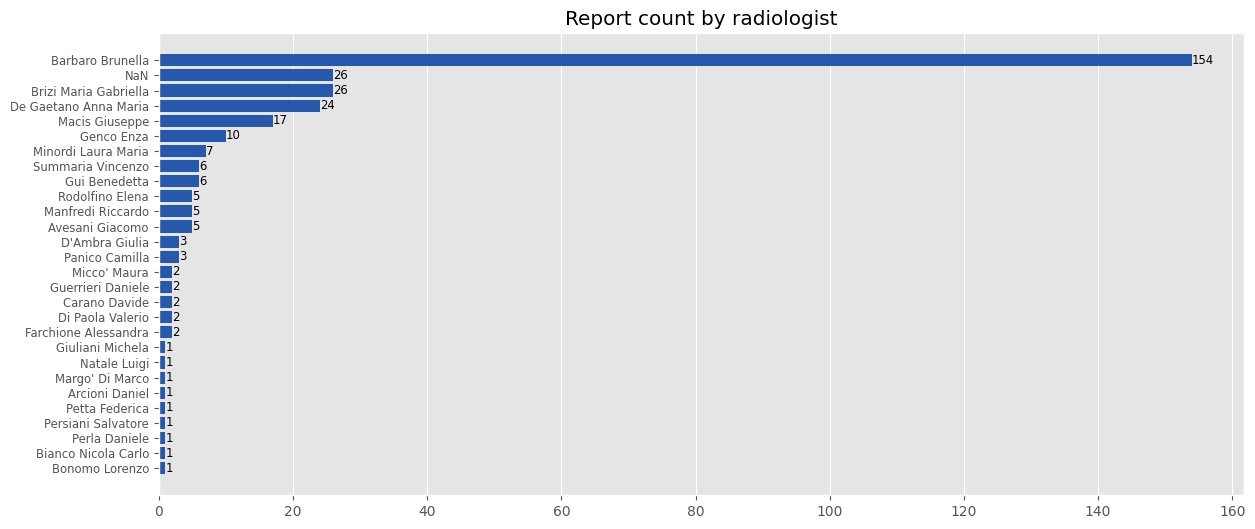

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))
val_counts = data_x['radiologist'].value_counts()
names = val_counts.index.tolist()
quantity = val_counts.values.tolist()
y_pos = np.arange(len(names))
hbars = ax.barh(y_pos, list(val_counts.values))
ax.bar_label(hbars, fontsize='small')
ax.set_yticks(y_pos, list(val_counts.index), fontsize='small')
ax.invert_yaxis()
ax.set_title('Report count by radiologist')
ax.grid(axis='y')
plt.show()

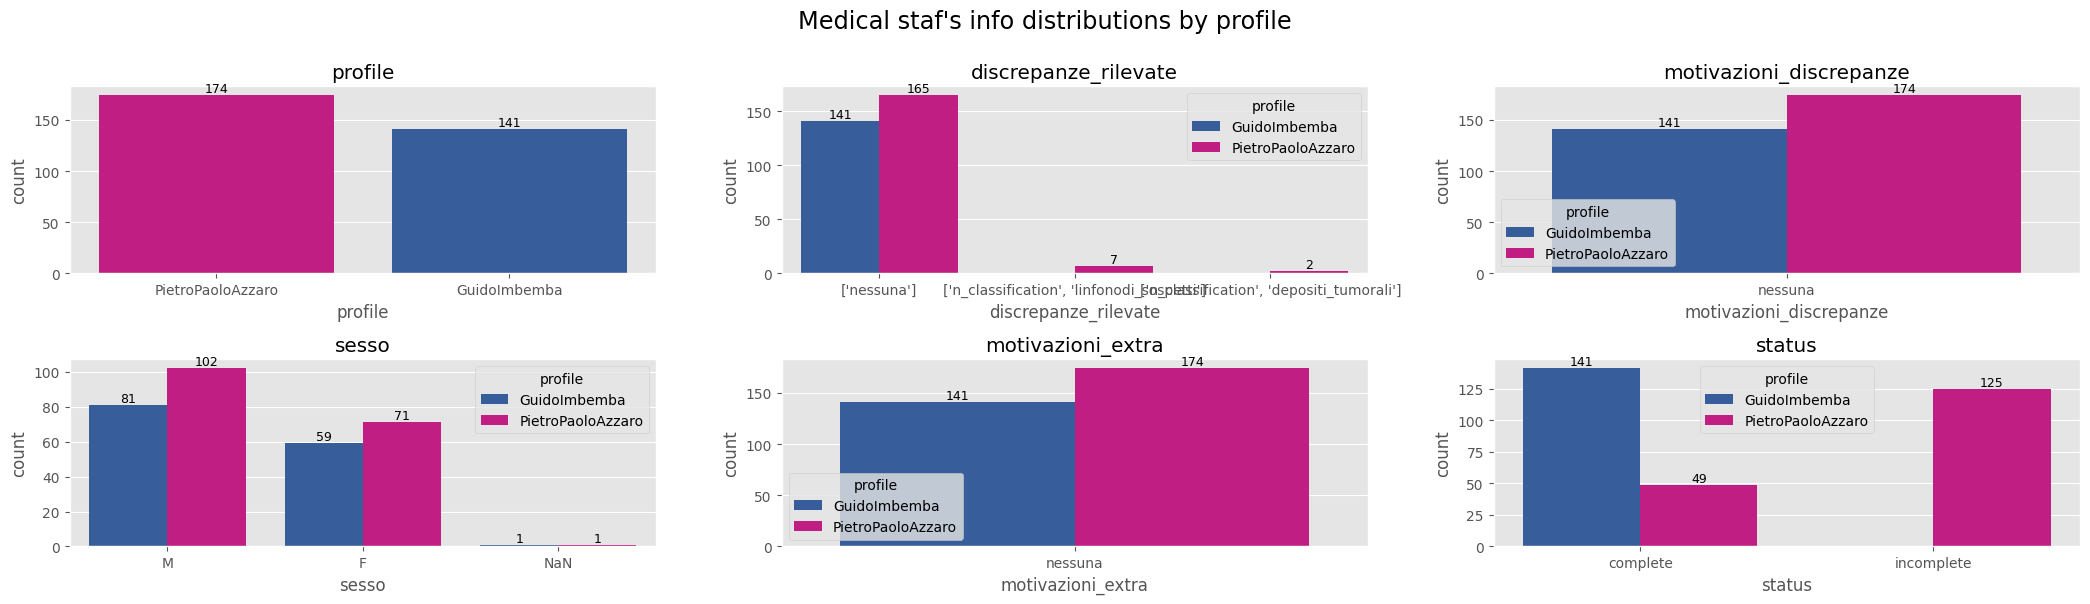

In [32]:
columns_plot = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'sesso', 'motivazioni_extra', 'status']

include_ilaria = False
df = data_plot
if include_ilaria:
    df = data_x


# hue_column = 'depositi_tumorali'
hue_column = 'profile'  # oppure il nome della colonna

n_columns = 3
n_rows = int(np.ceil(len(columns_plot) / n_columns))

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns * 7, n_rows * 3))
axes = axes.flatten()  # semplifica l'indicizzazione

for ax, col in zip(axes, columns_plot):
    order = df[col].value_counts().index
    sns.countplot(
        data=df,
        x=col,
        order=order,
        ax=ax,
        hue=hue_column
    )
    # Aggiunta etichette sulle barre (funziona anche con hue)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                height,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    ax.set_title(col)
    #ax.tick_params(axis='x', rotation=45)

# Rimuove eventuali assi vuoti
for j in range(len(columns_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Medical staf's info distributions by profile", fontsize='xx-large', y=1)
plt.tight_layout()
plt.show()

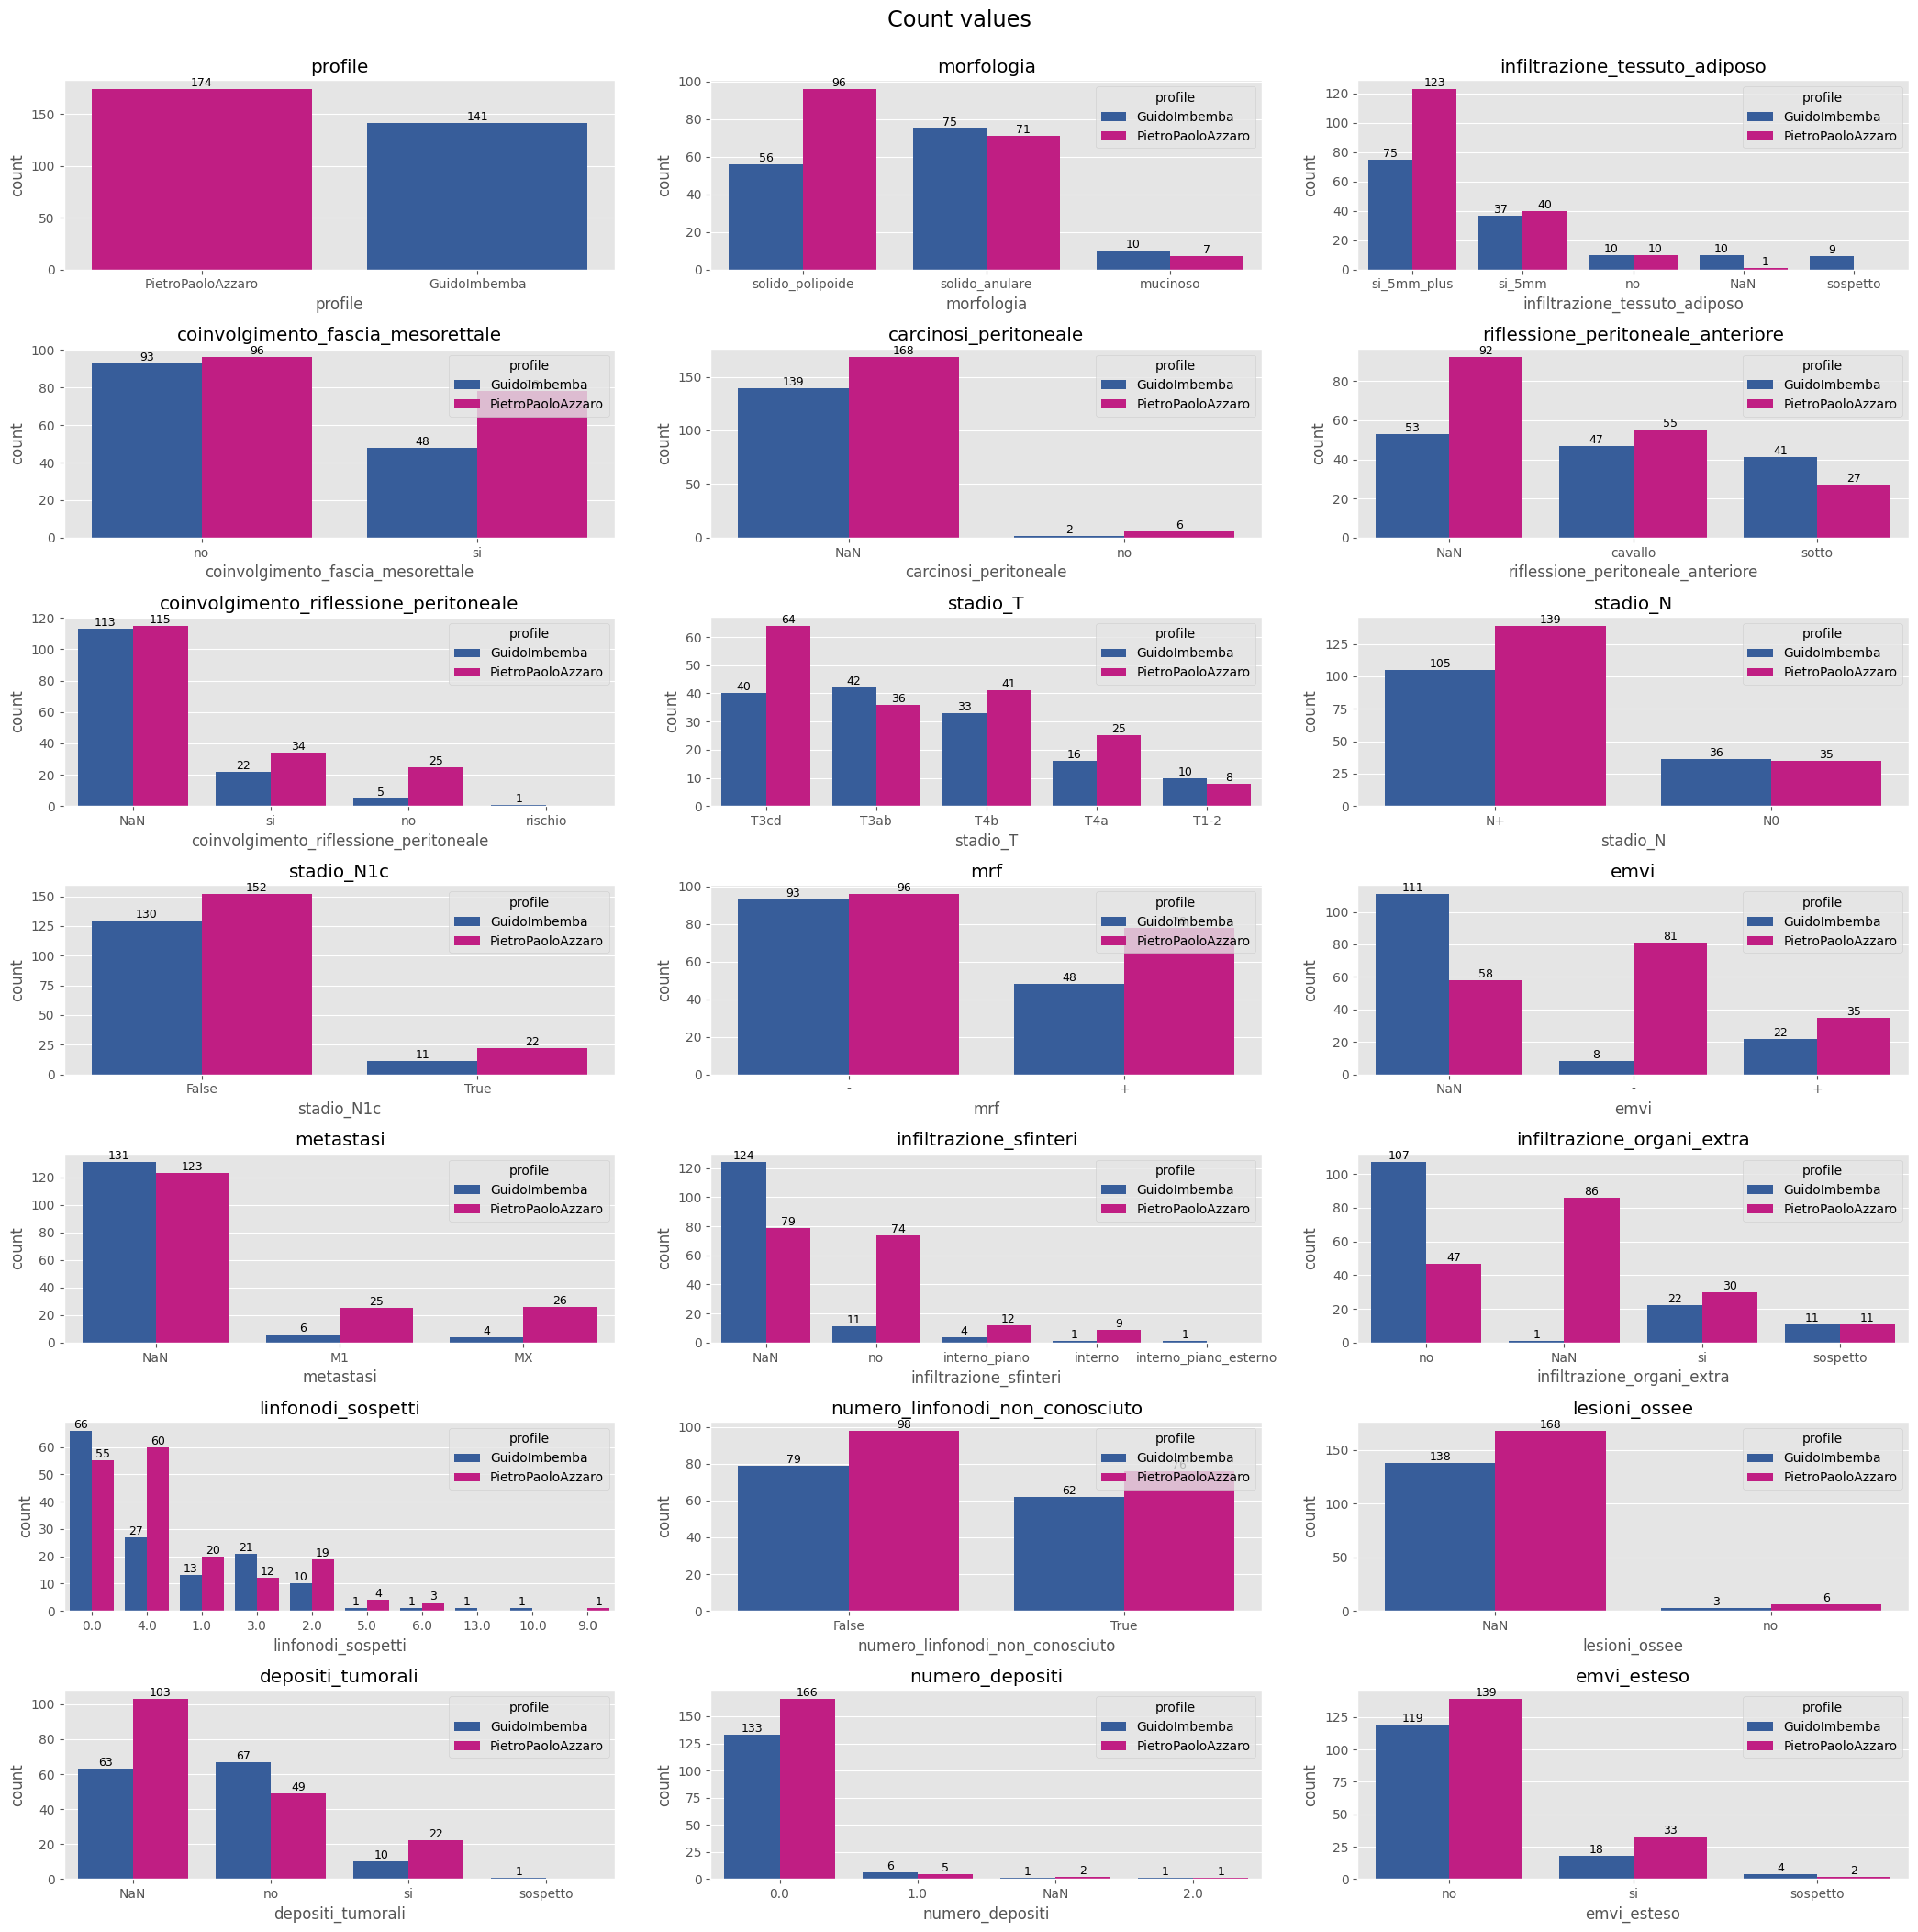

In [33]:
columns_plot = ['profile', 'morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']


# hue_column = 'depositi_tumorali'
hue_column = 'profile'  # oppure il nome della colonna

n_columns = 3
n_rows = int(np.ceil(len(columns_plot) / n_columns))

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns * 7, n_rows * 3))
axes = axes.flatten()  # semplifica l'indicizzazione

for ax, col in zip(axes, columns_plot):
    order = data_plot[col].value_counts().index
    sns.countplot(
        data=data_plot,
        x=col,
        order=order,
        ax=ax,
        hue=hue_column
    )
    # Aggiunta etichette sulle barre (funziona anche con hue)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                height,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    ax.set_title(col)
    #ax.tick_params(axis='x', rotation=45)

# Rimuove eventuali assi vuoti
for j in range(len(columns_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Count values", fontsize='xx-large', y=1)
plt.tight_layout()
plt.show()

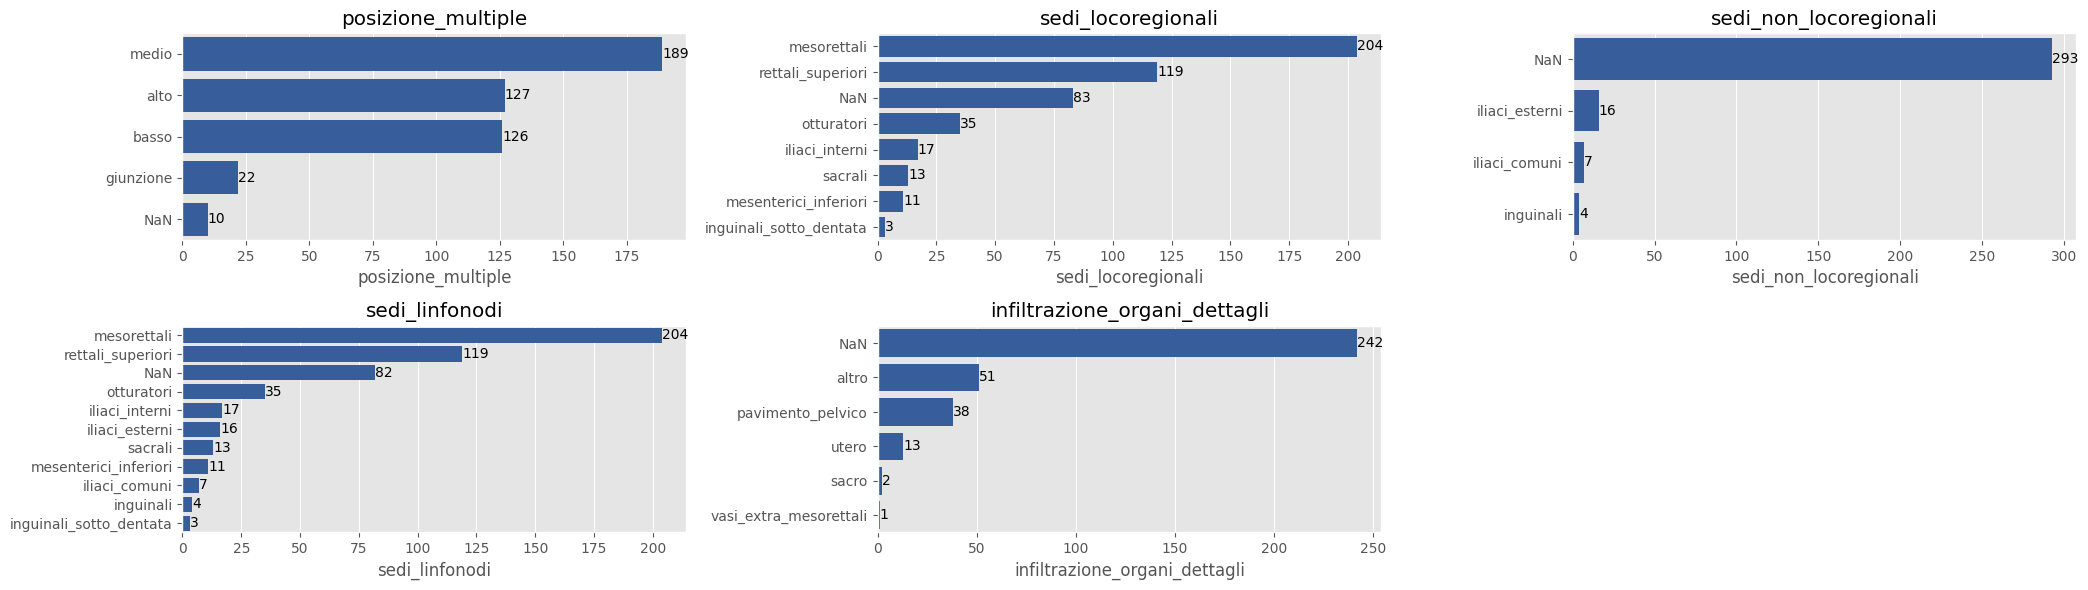

In [34]:
# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
            
# Dettagli organi
dettagli_organi = {'NaN'}
altri_organi = set()
for s in data_x.infiltrazione_organi_dettagli.fillna('NaN').value_counts().index:
    if s != 'NaN' and s != 'nan':
        d = ast.literal_eval(s)
        #print('---')
        dettagli_organi.update(d.keys())
        if 'altro' in d:
            altri_organi.add(d['altro'])
            
dettagli_organi_counts = {val: 0 for val in dettagli_organi}
for s in data_x.infiltrazione_organi_dettagli.fillna('NaN'):
    if s == 'NaN' or s == 'nan':
        dettagli_organi_counts['NaN'] += 1
    else:
        d = ast.literal_eval(s)
        for key in dettagli_organi:
            if key in d:
                dettagli_organi_counts[key] += 1

counts['infiltrazione_organi_dettagli'] = dettagli_organi_counts
columns.append('infiltrazione_organi_dettagli')
         
         
n_columns = 3
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns * 7, n_rows * 3))
axes = axes.flatten()  # semplifica l'indicizzazione
orientation = 'h'
for i, col in enumerate(columns):
    ax=axes[i]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation)
    ax.set_title(col)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

# Rimuove eventuali assi vuoti
for j in range(len(columns), n_columns * n_rows):
    fig.delaxes(axes[j])
            

plt.tight_layout()
plt.show()

Idea: uniamo sedi locoregionali e non locoregionali e manteniamo solo alcune classi: mesorettali, rettali_superiori, NaN, otturatori, iliaci. I restanti li metteremo in "altro".

Per quanto riguarda i dettagli dell'infiltrazione organi, teniamo solo le classi NaN, pavimento_pelvico, altro.

# Aggregazione / modifica delle colonne

AGGREGAZIONI

In generale possiamo aggregare NaN con "no" e "-"
- morfologia: va bene così: solido polipoide, solido anulare e mucinoso
- infiltrazione tessuto adiposo: aggrego il sospetto con si_5mm e il no con il NaN.
- coinvolgimento fascia mesorettale: aggrego no con NaN e si con rischio.
- Carcinosi peritoneale va tolta perchè sono presenti solo no e NaN.
- riflessione peritoneale anteriore: mantengo le classi NaN, cavallo e sotto
- coinvolgimento riflessione peritoneale: aggrego no con NaN e si con rischio
- stadio T: Ilaria dice di eventualmente aggregare gli stadi T3, tenendo separati gli stadi T4.
- stadio N: aggrego N1a con N1b e N2a con N2b, oppure lascio solo due classi: N0 e N+
- stadio N1c: non c'è niente da aggregare  (di fatto coincide con il campo depositi tumorali)
- mrf: tengo solo + e -
- emvi: aggrego - con NaN
- Metastasi: aggrego MX con NaN
- Infiltrazione sfinteri: aggrego no con NaN e tutte le altre categorie le faccio diventare si
- Infiltrazione organi extra: aggrego no con NaN e sospetto con si
- linfonodi sospetti: aggrego NaN con 0, ed eventualmente discretizzo in 2 fasce
- numero linfonodi non conosciuto: va bene così
- lesioni ossee andra rimossa perchè poco significativa
- depositi tumorali: aggrego NaN con no e si con sospetto
- numero depositi: aggrego 0 con NaN ma andrà rimosso perchè troppo sbilanciato
- Emvi esteso: aggrego si con sospetto ma di fatto coincide con il campo emvi, per cui uno di questi è ridondante

In [35]:
data_clean.loc[data_clean.fillna('NaN')['infiltrazione_organi_dettagli'].str.contains('elevatore')]['infiltrazione_organi_dettagli']

id
182    {'altro': "muscolo elevatore dell'ano", 'pavim...
208    {'altro': "muscolo elevatore dell'ano ; vagina...
213    {'altro': "non si apprezza clivaggio con il mu...
330    {'altro': "e il muscolo elevatore dell'ano", '...
336    {'altro': "muscolo elevatore dell'ano", 'pavim...
340    {'altro': "muscolo elevatore dell'ano", 'pavim...
348    {'altro': "muscolo elevatore dell'ano", 'pavim...
349    {'altro': "muscolo elevatore dell'ano", 'pavim...
359    {'altro': "elevatore dell'ano", 'pavimento_pel...
387    {'altro': "muscolo elevatore dell'ano", 'pavim...
394    {'altro': "nello specifico il muscolo elevator...
397    {'altro': "muscolo elevatore dell'ano", 'pavim...
399    {'altro': "muscolo elevatore dell'ano di destr...
411    {'altro': "nello specifico il muscolo elevator...
418    {'altro': "muscolo elevatore dell'ano.", 'pavi...
Name: infiltrazione_organi_dettagli, dtype: object

In [37]:
# Dettagli infiltrazione organi
infiltrazione_organi_dettagli_new = []
for s in data_clean.infiltrazione_organi_dettagli.fillna('NaN'):
    dettagli = []
    if s == 'NaN':
        infiltrazione_organi_dettagli_new.append(str(dettagli))
    else:
        d = ast.literal_eval(s)
        if 'pavimento_pelvico' in d:
            dettagli.append('pavimento_pelvico')
        if ('altro' in d) or ('utero' in d) or ('sacro' in d):
            if 'altro' in d:
                if 'muscolo elevatore' in d['altro']:
                    dettagli.append('muscolo_elevatore')
                else:
                    dettagli.append('altro')
            else:
                dettagli.append('altro')
        infiltrazione_organi_dettagli_new.append(str(dettagli))
data_clean.loc[:, 'infiltrazione_organi_dettagli'] = infiltrazione_organi_dettagli_new

# Sedi linfonodi
sedi_linfonodi_new = []
for s in data_clean.sedi_linfonodi:
    sedi = ast.literal_eval(s)
    sedi_new = set()
    for sede in sedi:
        if sede in ['mesorettali', 'rettali_superiori', 'otturatori']:
            sedi_new.add(sede)
        elif sede in ['iliaci_comuni', 'iliaci_interni', 'iliaci_esterni']:
            sedi_new.add('iliaci')
        else:
            sedi_new.add('altro')
    sedi_linfonodi_new.append(str(list(sedi_new)))
data_clean.loc[:, 'sedi_linfonodi'] = sedi_linfonodi_new

# infiltrazione tessuto adiposo
data_clean.loc[data_clean['infiltrazione_tessuto_adiposo'] == 'sospetto', 'infiltrazione_tessuto_adiposo'] = 'si_5mm'
data_clean.loc[data_clean['infiltrazione_tessuto_adiposo'].isna(), 'infiltrazione_tessuto_adiposo'] = 'no'

# Coinvolgimento fascia mesorettale. Trasformiamo rischio in si
#data_clean.loc[(data_clean['coinvolgimento_fascia_mesorettale'] == 'rischio'), 'coinvolgimento_fascia_mesorettale'] = 'si'
#data_clean.loc[(data_clean['coinvolgimento_fascia_mesorettale'].isna()) & (data_clean['mrf'] == '+'), 'coinvolgimento_fascia_mesorettale'] = 'si'
#data_clean.loc[(data_clean['coinvolgimento_fascia_mesorettale'].isna()) & (data_clean['mrf'] == '-'), 'coinvolgimento_fascia_mesorettale'] = 'no'

# Carcinosi peritoneale
data_clean.loc[data_clean['carcinosi_peritoneale'].isna(), 'carcinosi_peritoneale'] = 'no'

# Coinvolgimento riflessione peritoneale. Trasformiamo rischio in si
data_clean.loc[data_clean['coinvolgimento_riflessione_peritoneale'] == 'rischio', 'coinvolgimento_riflessione_peritoneale'] = 'si'
data_clean.loc[data_clean['coinvolgimento_riflessione_peritoneale'].isna(), 'coinvolgimento_riflessione_peritoneale'] = 'no'

# Infiltrazione sfinteri. Trasformiamo la posizione in si. per otenere una classe (si/no/NaN)
data_clean.loc[data_clean['infiltrazione_sfinteri'] == 'interno_piano', 'infiltrazione_sfinteri'] = 'si'
data_clean.loc[data_clean['infiltrazione_sfinteri'] == 'interno', 'infiltrazione_sfinteri'] = 'si'
data_clean.loc[data_clean['infiltrazione_sfinteri'] == 'interno_piano_esterno', 'infiltrazione_sfinteri'] = 'si'
data_clean.loc[data_clean['infiltrazione_sfinteri'].isna(), 'infiltrazione_sfinteri'] = 'no'

# Depositi tumorali
data_clean.loc[data_clean['depositi_tumorali'].isna(), 'depositi_tumorali'] = 'no'
data_clean.loc[data_clean['depositi_tumorali'] == 'sospetto', 'depositi_tumorali'] = 'si'

# Numero depositi
data_clean.loc[data_clean['numero_depositi'].isna(), 'numero_depositi'] = 0

# Stadio N
data_clean.loc[data_clean['stadio_N'] == 'N1a', 'stadio_N'] = 'N+'
data_clean.loc[data_clean['stadio_N'] == 'N1b', 'stadio_N'] = 'N+'
data_clean.loc[data_clean['stadio_N'] == 'N2a', 'stadio_N'] = 'N+'
data_clean.loc[data_clean['stadio_N'] == 'N2b', 'stadio_N'] = 'N+'
data_clean.loc[data_clean['depositi_tumorali'] == 'si', 'stadio_N'] = 'N+'

# Emvi
data_clean.loc[data_clean['emvi_esteso'] == 'sospetto', 'emvi_esteso'] = 'si'
data_clean.loc[data_clean['emvi'].isna(), 'emvi'] = '-'
data_clean.loc[data_clean['emvi_esteso'] == 'si', 'emvi'] = '+'

# Metastasi
data_clean.loc[data_clean['metastasi'].isna(), 'metastasi'] = 'MX'

# Infiltrazione organi extra
data_clean.loc[data_clean['infiltrazione_organi_extra'].isna(), 'infiltrazione_organi_extra'] = 'no'
data_clean.loc[data_clean['infiltrazione_organi_extra'] == 'sospetto', 'infiltrazione_organi_extra'] = 'si'

# Lesioni ossee
data_clean.loc[data_clean['lesioni_ossee'].isna(), 'lesioni_ossee'] = 'no'

In [38]:
# Fill NaN for plotting purposes
data_plot = data_clean.fillna('NaN')
data_ilaria = data_plot[data_plot['profile'] == 'IlariaNacci']
data_plot = data_plot.drop(index=data_plot[data_plot['profile'] == 'IlariaNacci'].index)
data_x = pd.concat([data_plot, data_ilaria])

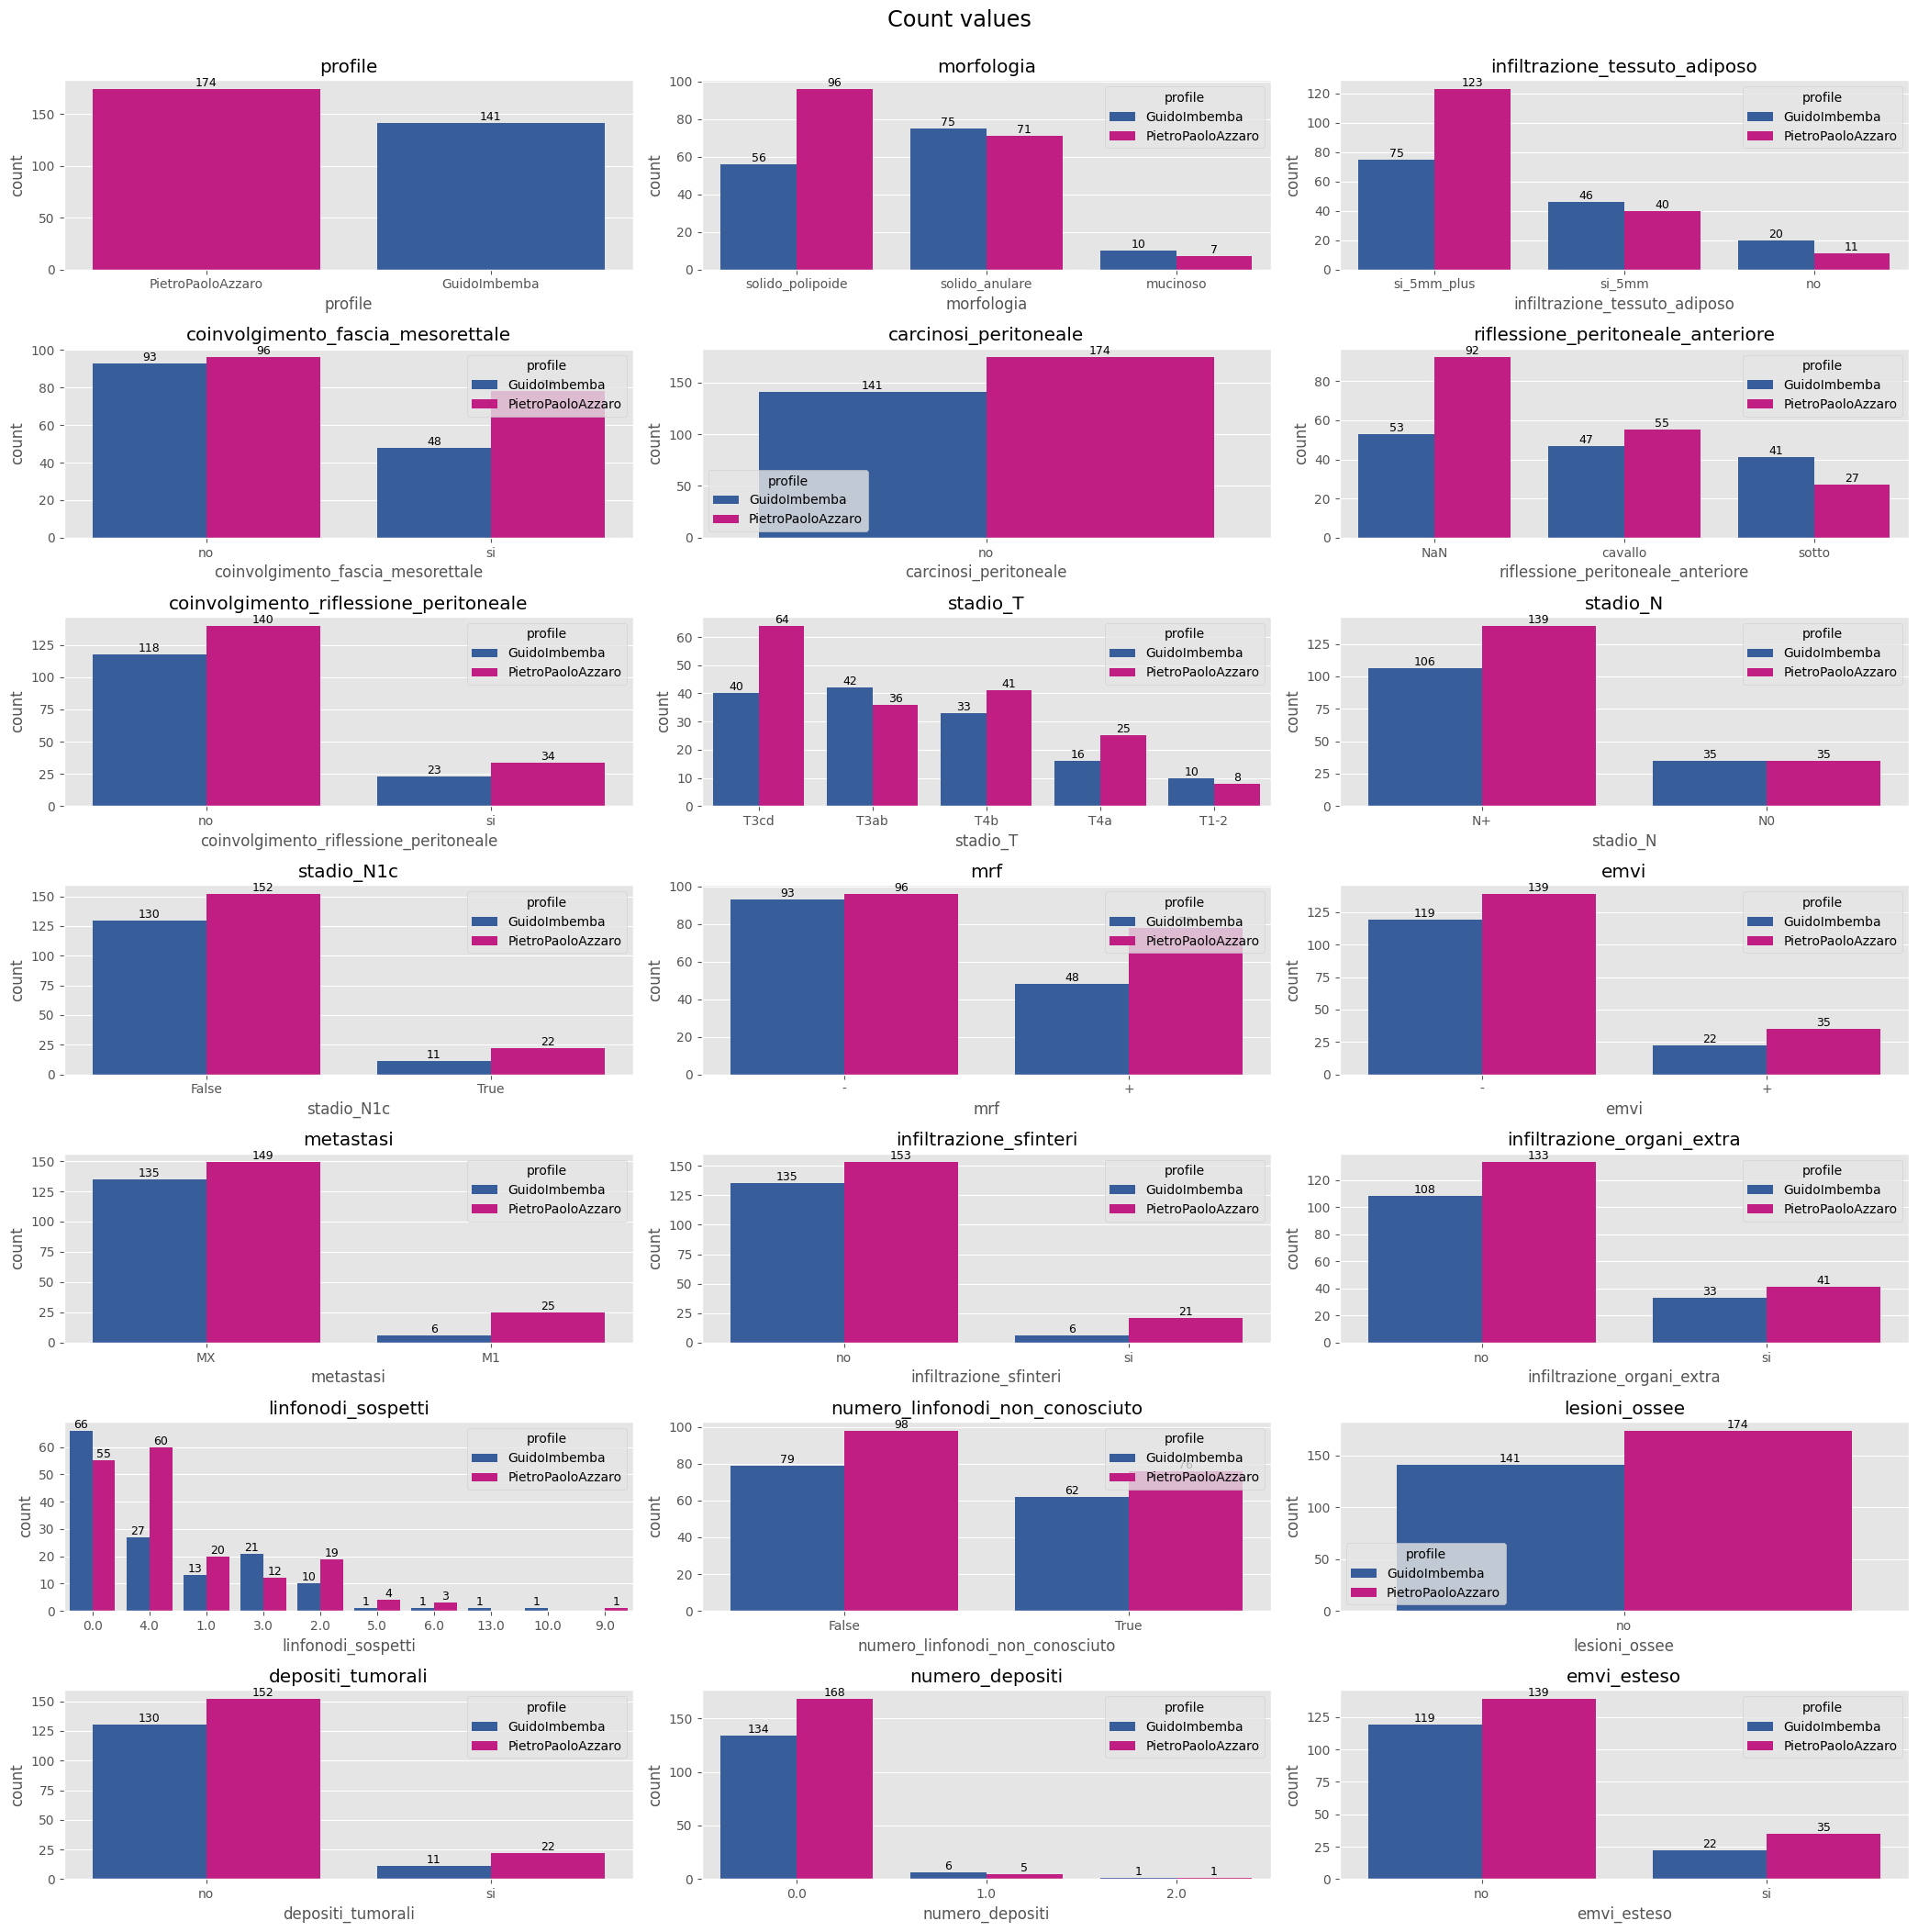

In [39]:
columns_plot = ['profile', 'morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']


# hue_column = 'depositi_tumorali'
hue_column = 'profile'  # oppure il nome della colonna
#hue_column = 'numero_linfonodi_non_conosciuto'  # oppure il nome della colonna

n_columns = 3
n_rows = int(np.ceil(len(columns_plot) / n_columns))

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns * 7, n_rows * 3))
axes = axes.flatten()  # semplifica l'indicizzazione

for ax, col in zip(axes, columns_plot):
    order = data_plot[col].value_counts().index
    sns.countplot(
        data=data_plot,
        x=col,
        order=order,
        ax=ax,
        hue=hue_column
    )
    # Aggiunta etichette sulle barre (funziona anche con hue)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                height,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    ax.set_title(col)
    #ax.tick_params(axis='x', rotation=45)

# Rimuove eventuali assi vuoti
for j in range(len(columns_plot), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Count values", fontsize='xx-large', y=1)
plt.tight_layout()
plt.show()

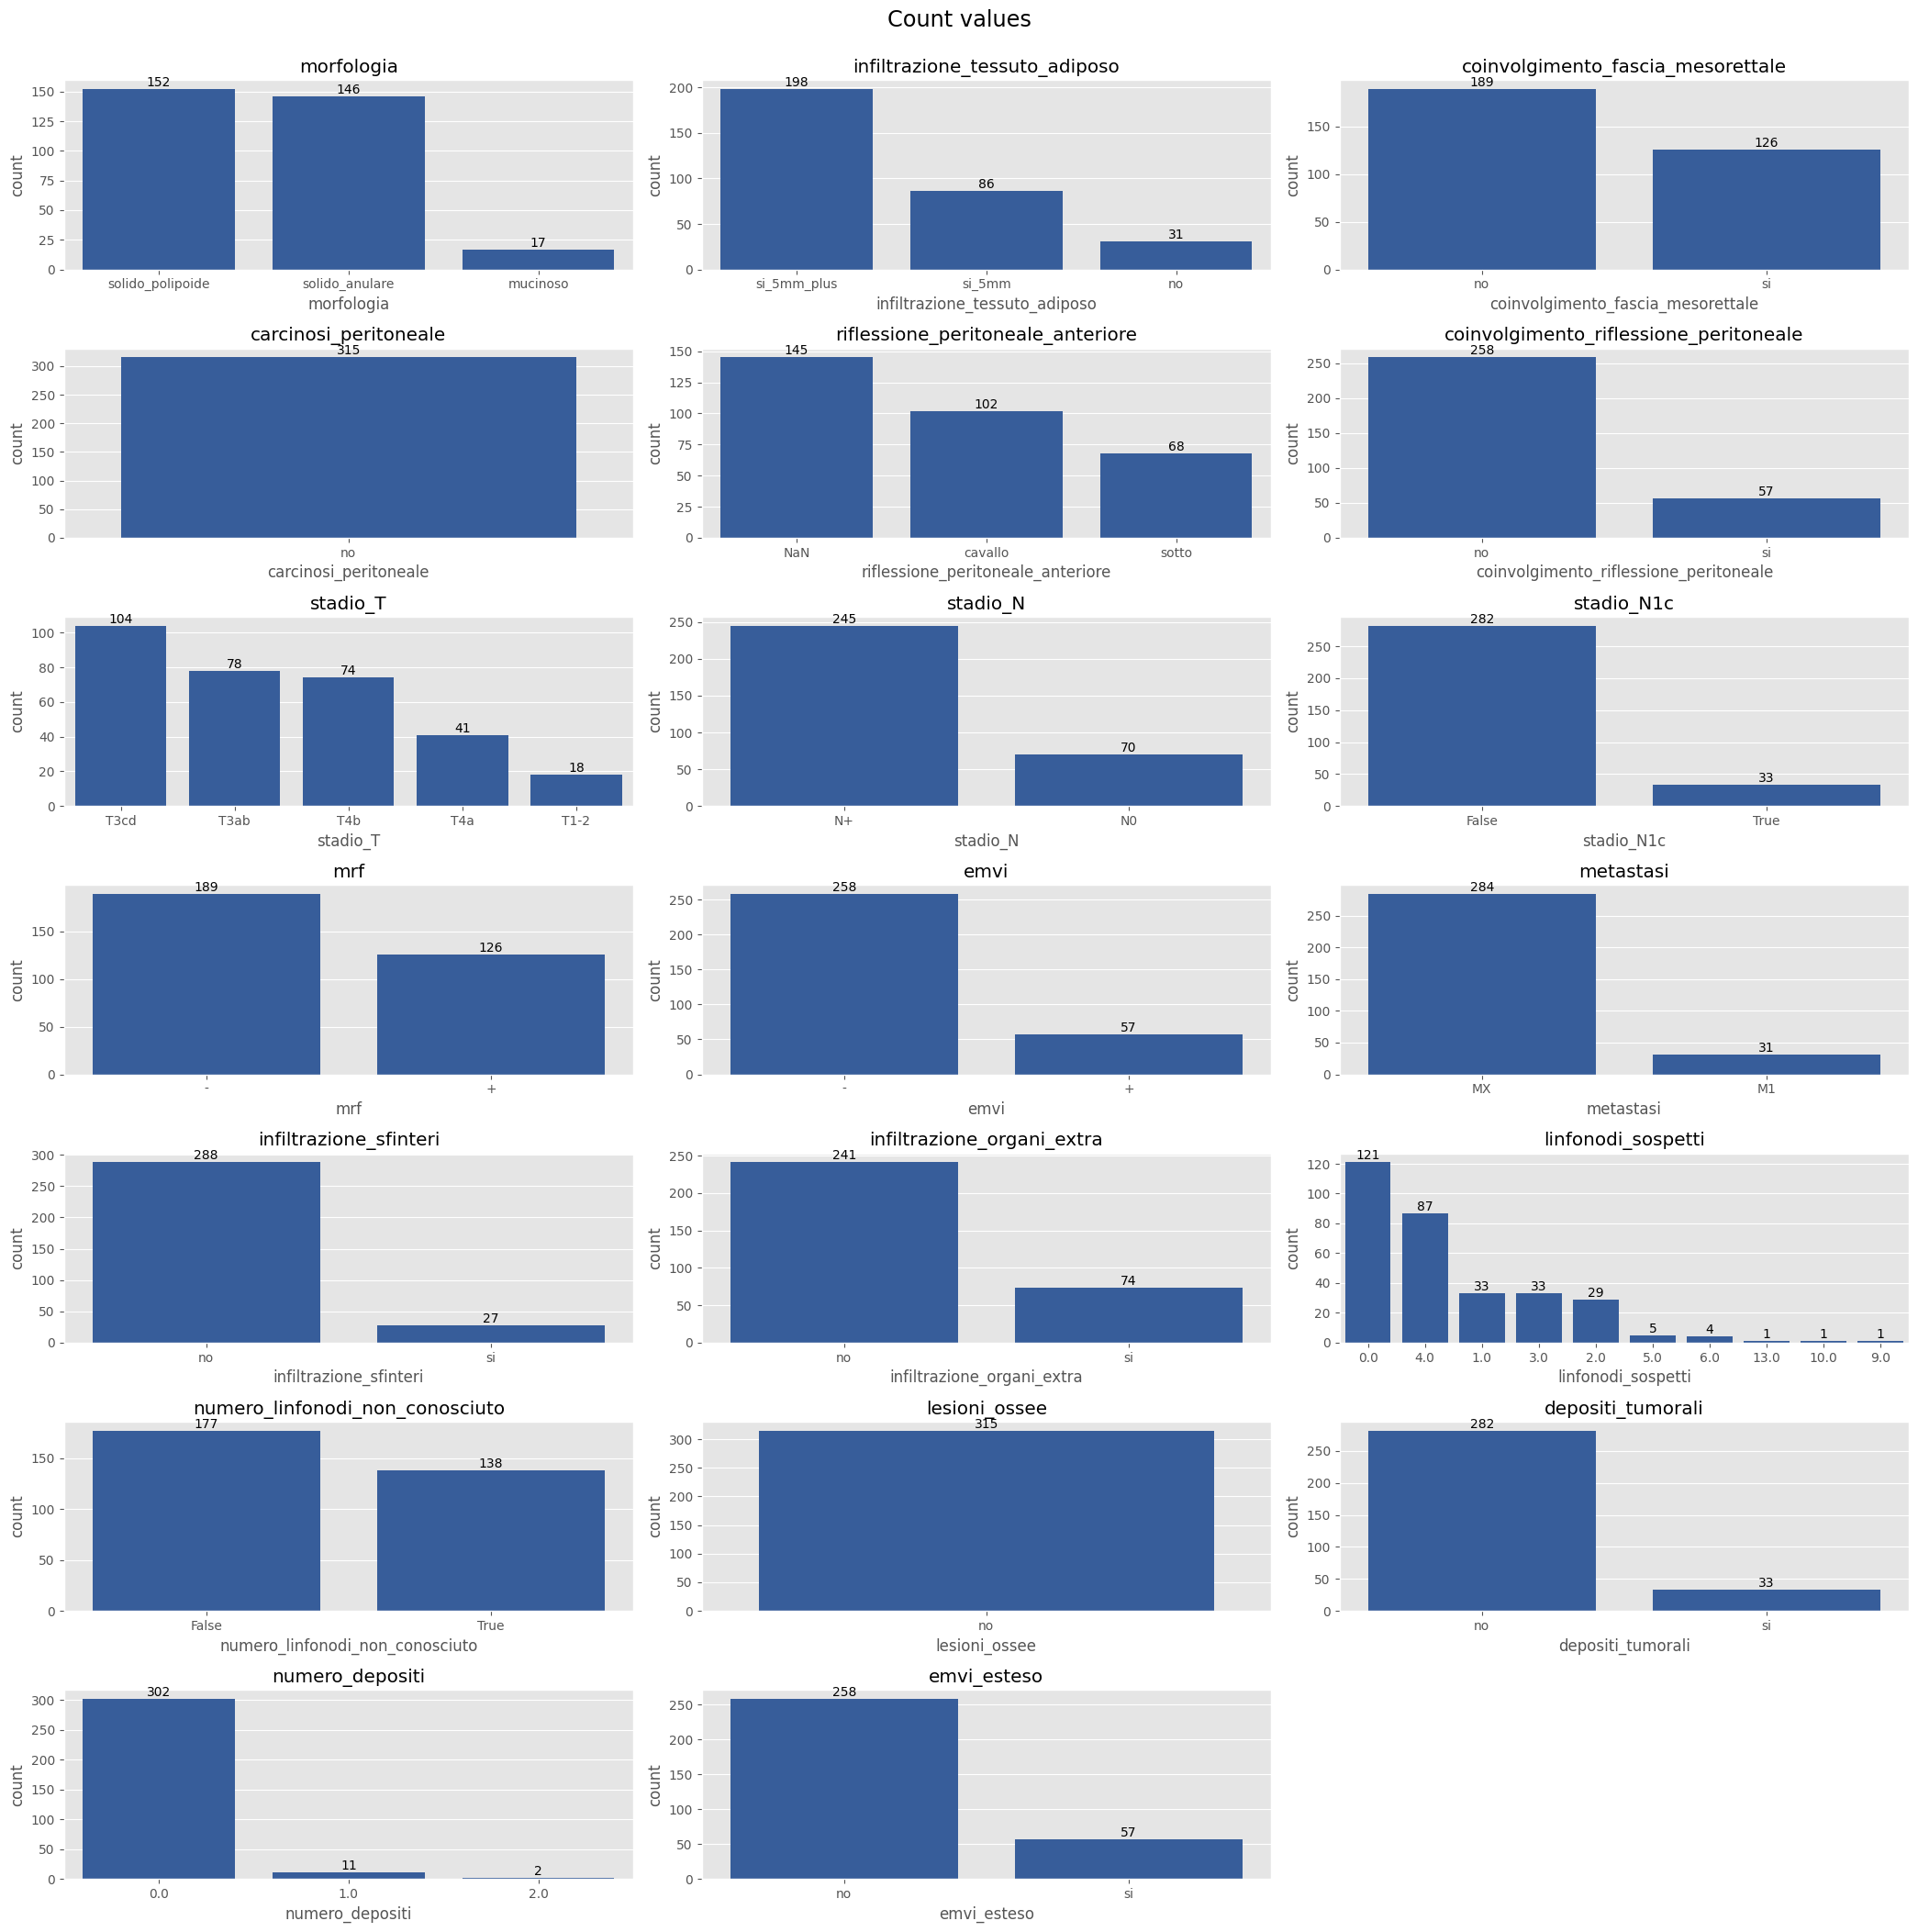

In [40]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']


n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
axes = axes.flatten()
fig.suptitle("Count values", fontsize='xx-large', y=1)

for i, col in enumerate(columns_plot):
    ax=axes[i]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax)
    ax.set_title(col)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

# Rimuove eventuali assi vuoti
for j in range(len(columns_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

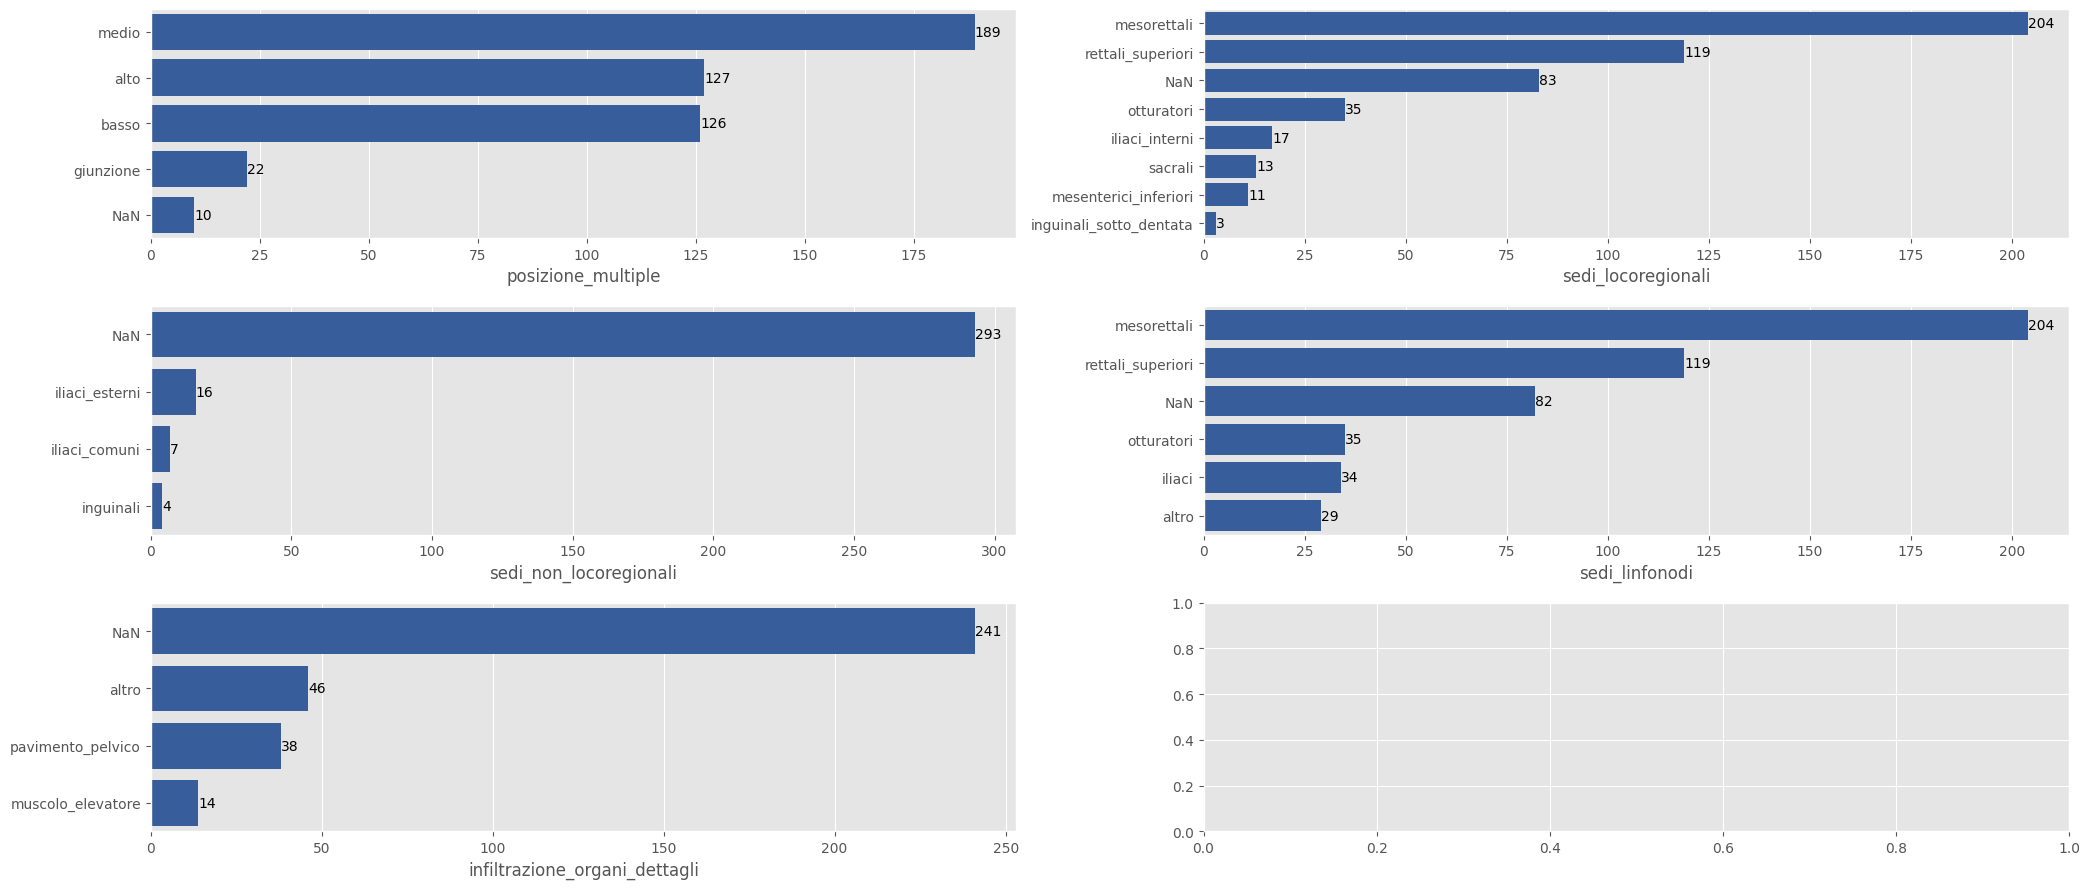

In [41]:
# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi', 'infiltrazione_organi_dettagli']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
         
         
n_columns = 2
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*3))
orientation = 'h'
for i, col in enumerate(columns):
    ax=axes[i//n_columns][i%n_columns]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

plt.tight_layout()
plt.show()

## Colonne target numeriche

In [42]:
colonne_target_numeriche = ['ore_inizio', 'ore_fine', 'dimensione_dll',
    'dimensione_dap', 'spessore_parietale', 'estensione_cranio_caudale',
    'distanza_oai', 'distanza_minima_fascia_ore',
    'linfonodi_sospetti', 'numero_depositi']

In [43]:
display(data_clean[colonne_target_numeriche].describe().T)
display(data_clean[colonne_target_numeriche].dtypes)

,count,mean,std,min,25%,50%,75%,max
ore_inizio,226.0,8.694690,3.607359,1.0,6.0,9.0,12.00,12.0
ore_fine,226.0,8.668142,3.857524,1.0,6.0,10.0,12.00,12.0
dimensione_dll,16.0,41.375000,22.582811,15.0,28.0,38.0,45.75,105.0
dimensione_dap,13.0,48.000000,28.760505,21.0,30.0,38.0,53.00,120.0
spessore_parietale,49.0,19.795918,11.436381,6.0,13.0,18.0,22.00,60.0
estensione_cranio_caudale,304.0,48.907895,16.721108,18.0,40.0,48.0,57.25,130.0
distanza_oai,292.0,43.191781,28.929661,0.0,20.0,45.0,60.75,110.0
distanza_minima_fascia_ore,36.0,8.305556,3.258566,1.0,7.0,8.0,11.25,12.0
linfonodi_sospetti,316.0,1.977848,1.997494,0.0,0.0,2.0,4.00,13.0
numero_depositi,316.0,0.047468,0.240950,0.0,0.0,0.0,0.00,2.0


ore_inizio                    float64
ore_fine                      float64
dimensione_dll                float64
dimensione_dap                float64
spessore_parietale            float64
estensione_cranio_caudale     float64
distanza_oai                  float64
distanza_minima_fascia_ore    float64
linfonodi_sospetti            float64
numero_depositi               float64
dtype: object

escludere le segenti colonne perchè hanno troppi valori nulli:
- dimensione_dll
- dimensione_dap
- distanza_minima_fascia_ore

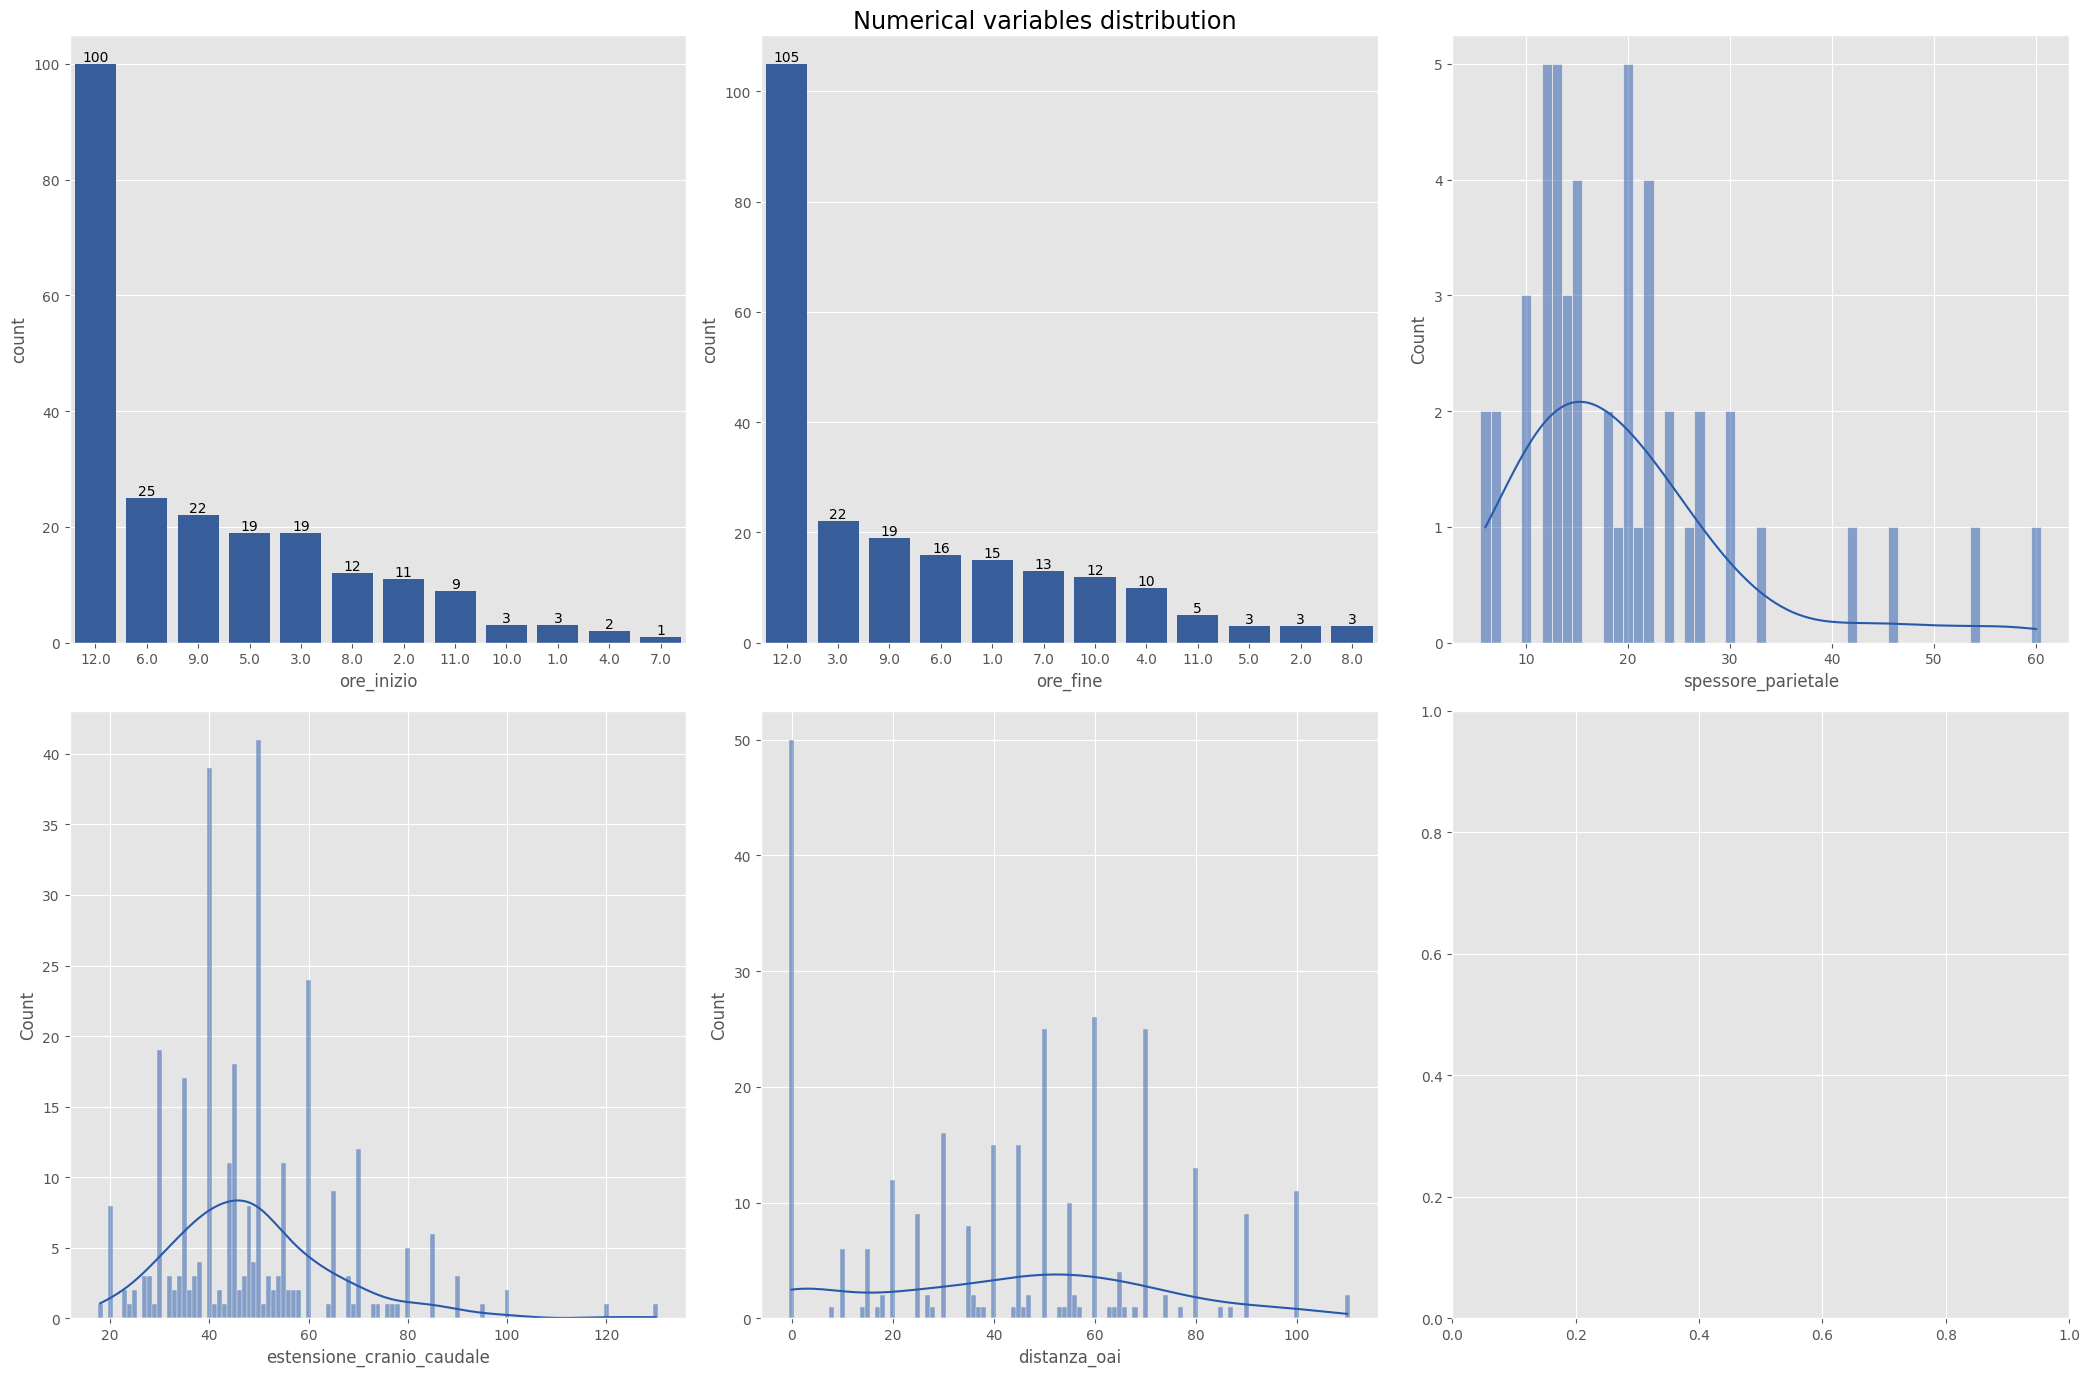

In [44]:
colonne_target_numeriche = ['ore_inizio', 'ore_fine',
    'spessore_parietale', 'estensione_cranio_caudale',
    'distanza_oai']

n_columns = 3
n_rows, r = divmod(len(colonne_target_numeriche), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*21/n_columns))
fig.suptitle("Numerical variables distribution", fontsize='xx-large')

for i, col in enumerate(colonne_target_numeriche):
    ax=axes[i//n_columns][i%n_columns]
    if len(data_clean[col].value_counts()) > 12:
        sns.histplot(data=data_clean, x=col, ax=ax, discrete=True, stat='count', kde=True)
    else:
        sns.countplot(data=data_clean, x=col, order=data_clean[col].value_counts().index, ax=ax)
        # Add values on top of bars
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()